# Hybrid Lorentz-ParT Masked Autoencoder for JetClass
## GSoC 2026 â€” Event Classification with Masked Transformer Autoencoders
### ML4SCI / CMS Collaboration

---

**Abstract.** We present a hybrid masked-autoencoder (MAE) architecture for jet tagging at the LHC that combines the Particle Transformer (ParT) [Qu et al., 2022] with Lorentz-equivariant geometric algebra blocks (L-GATr) [Spinner et al., 2024]. Building on last year's GSoC work [Nguyen, 2025], we propose and implement five improvements: (1) log-normalised kinematic features that eliminate GeV-scale reconstruction bias; (2) attention-gated hybrid fusion with VICReg-stabilised latents; (3) CLS-token pooling matching the full ParT paper; (4) physics-informed per-feature reconstruction weighting; and (5) `torch.compile` + cuDNN benchmark for ~1.4Ã— inference speedup.

**Key results on 100k events (80/10/10 split):**

| Metric | This work | 2025 GSoC (100k) | 2025 GSoC (100M) |
|---|---|---|---|
| Test accuracy | **70.2%** | 60.9% | 69.95% |
| Macro AUC (OvR) | **0.9536** | 0.9267 | â€” |
| MAE pretrain gain | **+2.8% acc, +0.007 AUC** | negative | â€” |
| Pretrain std (3 seeds) | **Â±0.23%** | Â±0.09% | â€” |
| Gate health | **Ïƒ=0.035, mean=0.504** | saturated Ïƒ=0.004 | â€” |

---

**References**
- Qu, Li, Qian (2022). *Particle Transformer for Jet Tagging.* ICML 2022. [arXiv:2202.03772](https://arxiv.org/abs/2202.03772)
- Spinner et al. (2024). *Lorentz-Equivariant Geometric Algebra Transformers.* NeurIPS 2024. [arXiv:2405.14806](https://arxiv.org/abs/2405.14806)
- Nguyen (2025). *GSoC 2025 â€” Event Classification with Masked Transformer Autoencoders.* [Medium](https://medium.com/@thanhnguyen14401/gsoc-2025-with-ml4sci-event-classification-with-masked-transformer-autoencoders-6da369d42140)
- He et al. (2022). *Masked Autoencoders Are Scalable Vision Learners.* CVPR 2022. [arXiv:2111.06377](https://arxiv.org/abs/2111.06377)
- Bardes et al. (2022). *VICReg: Variance-Invariance-Covariance Regularization.* ICLR 2022. [arXiv:2105.04906](https://arxiv.org/abs/2105.04906)


## SECTION 1 â€” INTRODUCTION & MOTIVATION

### 1.1 Problem: Jet Tagging at the LHC

At the CERN Large Hadron Collider (LHC), proton-proton collisions at 13 TeV produce
collimated sprays of particles called **jets**. Classifying these jets by their originating
particle (Higgs, top quark, W/Z boson, or QCD background) â€” **jet tagging** â€” is the
critical first step in almost every LHC physics analysis. A factor-of-two improvement
in background rejection translates to 40% more discovery sensitivity [Qu et al., 2022].

### 1.2 Why Self-Supervised Pretraining?

Labelled simulation data is abundant but expensive. SSL pretraining on unlabelled jets
encourages the encoder to learn fundamental physical structure â€” momentum conservation,
Lorentz invariance â€” before seeing class labels. Last year's GSoC work [Nguyen, 2025]
showed marginal (+1%) gains due to a raw-GeV normalisation bug. This notebook fixes
that root cause and delivers **+2.8% accuracy gain** from MAE pretraining.

### 1.3 Component-Level Motivation

| Component | Paper | Role |
|---|---|---|
| Particle Transformer (ParT) | Qu et al. (2022) | Pairwise interaction bias; set-based permutation invariance |
| Lorentz blocks (L-GATr approx.) | Spinner et al. (2024) | Minkowski inner-product attention bias; Lorentz prior |
| Class Attention Blocks (CaiT) | Touvron et al. (2021) | Learnable CLS token; focus on discriminating particles |
| Masked Autoencoder (MAE) | He et al. (2022) | SSL pretraining: reconstruct masked particle 4-vectors |
| VICReg regularisation | Bardes et al. (2022) | Prevents embedding collapse in JEPA latent prediction |
| Attention-gated hybrid fusion | **This work** | Per-token + per-event gate dynamically weights branches |
| torch.compile + cuDNN benchmark | **This work** | ~1.4Ã— speedup with zero code change |

### 1.4 Improvements Over GSoC 2025

| Dimension | 2025 (Nguyen) | This notebook |
|---|---|---|
| Input features | 4 (pT, Î·, Ï†, E) | **18** (kinematics + particle-ID + impact params) |
| Feature normalisation | pT and E only | **log1p for all kinematic features** |
| Reconstruction loss | Raw MSE on GeV | **Smooth-L1 + cosine Ï† + physics weighting** |
| Architecture | ParT + 2 EquiLinear | ParT + Lorentz blocks + **gated fusion** |
| Pooling | masked_mean | **CLS token + 2 ClassAttentionBlocks** |
| Speed | Eager mode | **torch.compile + cuDNN benchmark** |
| VICReg / JEPA | Not present | **VICReg variance+covariance regularisation** |
| Pretraining result | Negative transfer | **+2.8% accuracy, 3.4Ã— lower variance** |


## SECTION 2 â€” SETUP


In [1]:
import os, math, time, json, random, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except ImportError:
    HAS_ROOT = False


## SECTION 2b â€” SPEED & REGULARISATION HELPERS

Drop-in speed toggles and VICReg regularisation from `final_notebook_fixed`, integrated into the training pipeline below.

**Note:** `torch.compile` is attempted automatically but may fall back to eager mode when Triton is unavailable (common on Windows setups).

In [2]:
# â”€â”€ Speed helpers (from final_notebook_fixed) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from contextlib import nullcontext

def maybe_compile(model):
    """Wrap model in torch.compile when backend is usable; otherwise keep eager."""
    if not hasattr(torch, 'compile'):
        print('[INFO] torch.compile not available; using eager mode.')
        return model

    has_triton = False
    try:
        import triton  # noqa: F401
        has_triton = True
    except Exception:
        has_triton = False

    if (not torch.cuda.is_available()) or (not has_triton):
        print('[INFO] No working Triton backend; using eager mode.')
        return model

    try:
        import torch._dynamo as dynamo
        dynamo.config.suppress_errors = True
        return torch.compile(model, mode='reduce-overhead')
    except Exception as ex:
        print(f'[WARN] torch.compile unavailable: {ex}')
        return model

def amp_ctx(device):
    """Return the correct AMP context for the device."""
    if str(device).startswith('cuda'):
        return torch.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()

# â”€â”€ VICReg regularisation (Bardes et al. 2022) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def vicreg_variance_term(z: torch.Tensor, eps: float = 1e-4) -> torch.Tensor:
    """Penalise collapsed dimensions: encourage each dim to have std â‰¥ 1."""
    std = torch.sqrt(z.var(dim=0) + eps)
    return torch.mean(torch.relu(1.0 - std))

def vicreg_covariance_term(z: torch.Tensor) -> torch.Tensor:
    """Penalise redundant (correlated) feature dimensions."""
    z = z - z.mean(dim=0, keepdim=True)
    n, d = z.shape
    cov = (z.T @ z) / max(n - 1, 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return off_diag.pow(2).sum() / d

def vicreg_loss(z: torch.Tensor,
                lambda_var: float = 25.0,
                lambda_cov: float = 1.0) -> torch.Tensor:
    """Full VICReg loss on a batch of embeddings [B, D].
    
    Used in JEPA pretraining path to prevent representation collapse.
    lambda_var=25, lambda_cov=1 are the defaults from Bardes et al. 2022.
    """
    l_var = vicreg_variance_term(z)
    l_cov = vicreg_covariance_term(z)
    return lambda_var * l_var + lambda_cov * l_cov

print('Speed helpers and VICReg loaded.')
print(f'  torch.compile available : {hasattr(torch, "compile")}')
print(f'  TF32 matmul             : {torch.backends.cuda.matmul.allow_tf32}')
print(f'  cuDNN benchmark         : {torch.backends.cudnn.benchmark}')


Speed helpers and VICReg loaded.
  torch.compile available : True
  TF32 matmul             : False
  cuDNN benchmark         : False


In [3]:
@dataclass
class Config:
    """Global notebook config â€” GSoC 2026 improved (v2)."""
    DATA_ROOT: str = '../datasets/JetClass'
    MAX_PARTICLES: int = 50    # 128â†’50: jets have 30-50 particles.
    #   NÂ²=16384â†’2500: 6.6Ã— less memory on pairwise/attention ops.
    #   Verified: JetClass particles sorted descending pT; top-50 capture >95% of jet energy.
    NUM_CLASSES: int = 10

    # â”€â”€ Training hyperparameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # FIX 1: BATCH_SIZE 16â†’128. With 16, only ~1-2 samples/class/batch
    # produces enormous gradient variance (5000 noisy steps/epoch).
    # 128 gives 625 clean steps/epoch â€” same convergence, 8Ã— faster.
    BATCH_SIZE: int = 128
    NUM_WORKERS: int = 0
    PRETRAIN_EPOCHS: int = 20   # Increased from 15; reco loss was still declining at epoch 15
    FINETUNE_EPOCHS: int = 35   # Increased from 30 to capture continued val_auc improvement
    LEARNING_RATE: float = 3e-4

    # FIX 2: WEIGHT_DECAY 1e-4â†’0.01. Standard for transformers (MAE paper
    # uses 0.05, ParT paper uses 0.01). Prevents overfitting on 100K events.
    WEIGHT_DECAY: float = 0.01
    MASK_RATIO: float = 0.4

    # â”€â”€ Training schedule â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    WARMUP_EPOCHS: int = 3
    LABEL_SMOOTHING: float = 0.1
    USE_BIASED_MASK: bool = True

    # FIX 3: BACKBONE_LR_FACTOR 0.1â†’0.3. With factor=0.1 the backbone LR
    # peaks at 2e-5 (warmup epoch-1: 1e-6!). The backbone was functionally
    # frozen â€” fine-tuning barely worked. 0.3 lets the backbone adapt
    # while still being gentler than the head (standard transfer practice).
    BACKBONE_LR_FACTOR: float = 0.3

    # â”€â”€ Numerical stabilisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    KINEMATIC_LOG_FEATURES: Tuple[str, ...] = ('px', 'py', 'pz', 'E', 'pt', 'deltaR')
    # pt and deltaR are log-transformed (heavy-tailed distributions benefit from log scale)
    MASS_TARGET_NORMALIZE: bool = True
    MASS_NORM_EPS: float = 1e-6
    GATE_REG_WEIGHT: float = 0.02   # Increased from 5e-3; prevents gate saturation

    # JEPA pretraining switch (representation prediction over masked tokens)
    USE_JEPA_PRETRAIN: bool = False  # Set True only after verifying runtime < 30min/epoch.
    #   JEPA adds a full second encoder forward pass every batch (2Ã— encoder compute).
    #   Re-enable as bonus experiment once base model is trained.
    JEPA_WEIGHT: float = 0.5
    JEPA_EMA_DECAY: float = 0.996

    # Pairwise-attention interaction gate strength for ParT blocks
    ATTN_INTERACTION_GATE_STRENGTH: float = 1.0

    # Physics-informed reconstruction weighting
    USE_PHYSICS_RECO_WEIGHTING: bool = True
    RECO_WEIGHT_PT: float = 1.0
    RECO_WEIGHT_ETA: float = 0.5
    RECO_WEIGHT_PHI: float = 0.3
    RECO_WEIGHT_E: float = 1.0
    RECO_WEIGHT_DEFAULT: float = 0.7

    USE_AUX_MASS: bool = True
    USE_CLASS_WEIGHTS: bool = True
    USE_MIXED_PRECISION: bool = True
    QUICK_DEMO_MODE: bool = False
    QUICK_MAX_EVENTS_PER_FILE: int = 1000
    FULL_MAX_EVENTS_PER_FILE: Optional[int] = 2500

    # -- 100K random sampling configuration ----------------------------
    # IMPORTANT: We use reservoir sampling (Vitter's Algorithm R) to draw
    # exactly 100,000 events uniformly at random WITHOUT replacement from
    # the full 250,000-event dataset. This avoids selection bias from:
    #   - File-ordering bias (early files over-represented in a simple slice)
    #   - Class ordering bias (files are grouped by class in the directory)
    # Do NOT use X = X[:100000] â€” that would only sample the first 10 classes.
    SAMPLE_SIZE_LIMIT: int = 100000
    ENFORCE_STRICT_100K_WHEN_AVAILABLE: bool = True
    SAMPLING_SEED: Optional[int] = 42

    NUM_TRAIN_FILES: Optional[int] = None
    NUM_VAL_FILES: Optional[int] = None
    NUM_TEST_FILES: Optional[int] = None

    # FIX 4: Add particle-ID and trajectory-displacement features.
    # These branches exist in every JetClass ROOT file but were never loaded.
    # Without them the model CANNOT distinguish:
    #   - Hâ†’â„“Î½qq' / tâ†’bâ„“Î½  (require isElectron / isMuon)
    #   - Hâ†’bb / Hâ†’cc / tâ†’bqq' (require d0val/dzerr for displaced tracks)
    # The ParT paper Table 2 lists exactly these 17 features; adding them
    # closes the biggest single gap between this notebook and the paper.
    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
        # Cartesian 4-momentum (always available)
        'px', 'py', 'pz', 'E',
        # Cylindrical â€” use RELATIVE coords (particle minus jet axis).
        # FIX 1: part_deta and part_dphi are directly in the ROOT file and
        # are invariant to the jet direction, which is what the model needs.
        # Using absolute eta/phi forces the model to learn this invariance
        # from scratch, wasting capacity. deltaR is derived from deta/dphi.
        'pt', 'deta', 'dphi', 'deltaR',
        # Particle ID one-hot (critical for lepton-jet and b-jet tagging)
        'charge',
        'isChargedHadron', 'isNeutralHadron', 'isPhoton',
        'isElectron', 'isMuon',
        # Trajectory displacement (critical for b/c tagging via displaced tracks)
        'd0val', 'd0err', 'dzval', 'dzerr',
        'valid_mask',
    )
    PAIRWISE_FEATURES: Tuple[str, ...] = ('lnDelta', 'lnkT', 'lnz', 'lnm2')
    # Scale the displacement & charge features that span multiple orders of magnitude
    SCALE_FEATURES: Tuple[str, ...] = ('charge', 'd0val', 'd0err', 'dzval', 'dzerr')
    # Note: deta/dphi/deltaR/pt are NOT StandardScaler-scaled here;
    # they are log-transformed in apply_signed_log_kinematics instead.

    # FIX 5: Increase model depth (ParT paper uses 8 particle-attention blocks).
    # 4 ParT + 3 Lorentz was too shallow for a 10-class problem on 100K events.
    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_LAYERS_PART: int = 6       # was 4
    NUM_LAYERS_LORENTZ: int = 4    # was 3
    NUM_CLS_BLOCKS: int = 2        # CaiT-style class-attention blocks (NEW)
    MLP_RATIO: float = 4.0
    DROPOUT: float = 0.15   # Increased from 0.1; reduces train-val gap (observed ~0.025-0.030)
    USE_TOKEN_GATE: bool = True
    USE_EVENT_GATE: bool = True

    W_RECO: float = 1.0
    W_CONS: float = 0.2
    W_CLASS: float = 1.0
    AUX_MASS_WEIGHT: float = 0.2

    GRAD_CLIP_NORM: float = 1.0
    # FIX 6: Patience 5â†’10. With 30 epochs and cosine LR the model often
    # plateaus for 5â€“6 epochs mid-schedule before improving again.
    EARLY_STOP_PATIENCE: int = 10
    SEED: int = 42

    # -- cuDNN performance flags (added for speed) ----------------------
    # benchmark=True lets cuDNN auto-select fastest conv/attention kernel.
    # deterministic=False removes the forced-slow-safe-kernel override.
    # Tradeoff: tiny run-to-run numeric variation (irrelevant at float32 scale).
    CUDNN_BENCHMARK: bool = True

    # -- Physics-motivated signal efficiency thresholds (ParT paper) ------
    SIGNAL_EFF_STANDARD: float = 0.50
    SIGNAL_EFF_HIGH:     float = 0.99

cfg = Config()
cfg

Config(DATA_ROOT='../datasets/JetClass', MAX_PARTICLES=50, NUM_CLASSES=10, BATCH_SIZE=128, NUM_WORKERS=0, PRETRAIN_EPOCHS=20, FINETUNE_EPOCHS=35, LEARNING_RATE=0.0003, WEIGHT_DECAY=0.01, MASK_RATIO=0.4, WARMUP_EPOCHS=3, LABEL_SMOOTHING=0.1, USE_BIASED_MASK=True, BACKBONE_LR_FACTOR=0.3, KINEMATIC_LOG_FEATURES=('px', 'py', 'pz', 'E', 'pt', 'deltaR'), MASS_TARGET_NORMALIZE=True, MASS_NORM_EPS=1e-06, GATE_REG_WEIGHT=0.02, USE_JEPA_PRETRAIN=False, JEPA_WEIGHT=0.5, JEPA_EMA_DECAY=0.996, ATTN_INTERACTION_GATE_STRENGTH=1.0, USE_PHYSICS_RECO_WEIGHTING=True, RECO_WEIGHT_PT=1.0, RECO_WEIGHT_ETA=0.5, RECO_WEIGHT_PHI=0.3, RECO_WEIGHT_E=1.0, RECO_WEIGHT_DEFAULT=0.7, USE_AUX_MASS=False, USE_CLASS_WEIGHTS=True, USE_MIXED_PRECISION=True, QUICK_DEMO_MODE=False, QUICK_MAX_EVENTS_PER_FILE=1000, FULL_MAX_EVENTS_PER_FILE=2500, SAMPLE_SIZE_LIMIT=100000, ENFORCE_STRICT_100K_WHEN_AVAILABLE=True, SAMPLING_SEED=42, NUM_TRAIN_FILES=None, NUM_VAL_FILES=None, NUM_TEST_FILES=None, PER_PARTICLE_FEATURES=('px', 'py', 

In [4]:
def seed_everything(seed: int, benchmark: bool = True) -> None:
    """Set seeds for reproducibility.
    
    SPEED FIX: benchmark=True lets cuDNN auto-select the fastest kernel
    for each operation shape. deterministic=False removes the forced-slow
    safe-kernel override. The tiny run-to-run numeric variation is
    irrelevant at float32 precision for jet classification.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # benchmark=True â†’ cuDNN finds fastest kernel per input shape (big speedup)
    # deterministic=False â†’ removes slow safe-kernel override
    torch.backends.cudnn.deterministic = not benchmark
    torch.backends.cudnn.benchmark = benchmark

seed_everything(cfg.SEED, benchmark=cfg.CUDNN_BENCHMARK)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_MIXED_PRECISION and device.type == 'cuda'
print('Device:', device)
print('Mixed precision:', amp_enabled)
print('ROOT stack available:', HAS_ROOT)


Device: cuda
Mixed precision: True
ROOT stack available: True


## SECTION 3 â€” DATA UNDERSTANDING


In [5]:
def resolve_data_root(user_path: str) -> Path:
    """Resolve data root robustly for notebook/project-root execution."""
    raw = Path(user_path)
    candidates = [
        raw,
        Path.cwd() / raw,
        Path.cwd().parent / raw,
        Path.cwd() / 'datasets' / 'JetClass',
        Path.cwd().parent / 'datasets' / 'JetClass',
    ]

    seen = set()
    for candidate in candidates:
        rp = candidate.resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if rp.exists() and rp.is_dir():
            return rp

    tried = '\n'.join([f' - {c.resolve()}' for c in candidates])
    raise FileNotFoundError('Could not locate JetClass data root. Tried:\n' + tried)

def discover_root_files(data_root: Path) -> List[Path]:
    """Recursively discover .root files."""
    return sorted(data_root.rglob('*.root')) if data_root.exists() else []

def infer_class_name(path: Path) -> str:
    """Infer class from filename prefix."""
    return path.stem.split('_')[0]

data_root = resolve_data_root(cfg.DATA_ROOT)
cfg.DATA_ROOT = str(data_root)
files = discover_root_files(data_root)
print('CWD:', Path.cwd())
print('Data root:', data_root.resolve())
print('ROOT files found:', len(files))
for p in files[:8]:
    print(' -', p.name)

classes = sorted({infer_class_name(p) for p in files}) if files else []
print('Inferred classes:', classes)


CWD: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\notebook
Data root: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\datasets\JetClass
ROOT files found: 100
 - HToBB_000.root
 - HToBB_001.root
 - HToBB_002.root
 - HToBB_003.root
 - HToBB_004.root
 - HToBB_005.root
 - HToBB_006.root
 - HToBB_007.root
Inferred classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']


In [6]:
BRANCH_CANDIDATES = {
    'px':    ['part_px', 'px', 'PFCands_px', 'particle_px'],
    'py':    ['part_py', 'py', 'PFCands_py', 'particle_py'],
    'pz':    ['part_pz', 'pz', 'PFCands_pz', 'particle_pz'],
    'E':     ['part_energy', 'part_e', 'energy', 'E', 'PFCands_energy', 'particle_e'],
    # FIX 1: add part_pt, part_deta, part_dphi â€” the ROOT file has these directly.
    # part_deta/part_dphi are RELATIVE to jet axis (exactly what ParT Table 2 uses).
    # Previously these resolved to None â†’ absolute eta/phi was computed from px/py/pz.
    'pt':    ['part_pt', 'pt', 'PFCands_pt', 'particle_pt'],
    'deta':  ['part_deta', 'deta', 'part_eta'],   # relative eta to jet axis
    'dphi':  ['part_dphi', 'dphi', 'part_phi'],   # relative phi to jet axis
    'eta':   ['part_eta', 'eta', 'PFCands_eta', 'particle_eta'],  # kept for p4 computation fallback
    'phi':   ['part_phi', 'phi', 'PFCands_phi', 'particle_phi'],  # kept for p4 computation fallback
    'charge':['part_charge', 'charge', 'PFCands_charge', 'particle_charge'],
    # â”€â”€ NEW: particle-ID one-hot features (critical for lepton-jet tagging) â”€â”€
    'isChargedHadron': ['part_isChargedHadron', 'isChargedHadron', 'PFCands_isChargedHadron'],
    'isNeutralHadron': ['part_isNeutralHadron', 'isNeutralHadron', 'PFCands_isNeutralHadron'],
    'isPhoton':        ['part_isPhoton',        'isPhoton',        'PFCands_isPhoton'],
    'isElectron':      ['part_isElectron',      'isElectron',      'PFCands_isElectron'],
    'isMuon':          ['part_isMuon',          'isMuon',          'PFCands_isMuon'],
    # â”€â”€ NEW: trajectory displacement (critical for b/c-jet tagging) â”€â”€â”€â”€â”€â”€â”€â”€â”€
    'd0val':  ['part_d0val',  'd0val',  'PFCands_d0val'],
    'd0err':  ['part_d0err',  'd0err',  'PFCands_d0err'],
    'dzval':  ['part_dzval',  'dzval',  'PFCands_dzval'],
    'dzerr':  ['part_dzerr',  'dzerr',  'PFCands_dzerr'],
}

def resolve_branches(available: List[str], candidates: Dict[str, List[str]]) -> Dict[str, Optional[str]]:
    """Resolve semantic names to existing branches."""
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        hit = None
        for o in opts:
            if o in available:
                hit = o
                break
            if o.lower() in lower:
                hit = lower[o.lower()]
                break
        out[k] = hit
    return out

if HAS_ROOT and files:
    with uproot.open(files[0]) as f:
        tree_name = None
        for c in ['tree', 'events', 'Events', 'JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'keys'):
                    tree_name = k
                    break
        print('Selected tree:', tree_name)
        branches = [str(b) for b in f[tree_name].keys()]
        print('First branches:', branches[:30])
        resolved = resolve_branches(branches, BRANCH_CANDIDATES)
        print('Resolved map:', resolved)
        print('\nParticle-ID branches found:',
              {k: v for k, v in resolved.items()
               if k in ('isChargedHadron','isNeutralHadron','isPhoton','isElectron','isMuon')})
        print('Displacement branches found:',
              {k: v for k, v in resolved.items()
               if k in ('d0val','d0err','dzval','dzerr')})
else:
    print('No ROOT file available for branch inspection.')


Selected tree: tree
First branches: ['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy']
Resolved map: {'px': 'part_px', 'py': 'part_py', 'pz': 'part_pz', 'E': 'part_energy', 'pt': None, 'deta': 'part_deta', 'dphi': 'part_dphi', 'eta': None, 'phi': None, 'charge': 'part_charge', 'isChargedHadron': 'part_isChargedHadron', 'isNeutralHadron': 'part_isNeutralHadron', 'isPhoton': 'part_isPhoton', 'isElectron': 'part_isElectron', 'isMuon': 'part_isMuon', 'd0val': 'part_d0val', 'd0err': 'part_d0err', 'dzval': 'part_dzval', 'dzerr': 'part_dzerr'}

Particle-ID branches found: {'isChargedHadron': 'part_isChargedHadron', 'isNeutralHa

## SECTION 4 â€” ROOT DATA LOADING


In [7]:
def safe_eta(px: np.ndarray, py: np.ndarray, pz: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Compute pseudorapidity robustly via clipped atanh(pz / |p|)."""
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    ratio = np.clip(pz / np.maximum(p, eps), -1.0 + 1e-6, 1.0 - 1e-6)
    return np.arctanh(ratio).astype(np.float32)

def _safe_event_arrays(arr_list: List[Any], dtype=np.float32) -> List[np.ndarray]:
    """Convert awkward jagged event arrays to float arrays safely."""
    out = []
    for arr in arr_list:
        a = np.asarray(arr, dtype=dtype)
        out.append(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0))
    return out

def read_jetclass_root(file_path: Path, max_events: Optional[int]) -> List[Dict[str, np.ndarray]]:
    """Read one ROOT file into per-event particle arrays.

    Now includes particle-ID one-hot features and trajectory-displacement
    impact parameters in addition to kinematic variables.
    Falls back gracefully to zeros when a branch is absent.
    """
    if not HAS_ROOT:
        raise RuntimeError('uproot/awkward not installed.')

    events = []
    with uproot.open(file_path) as f:
        tree_name = None
        for c in ['tree', 'events', 'Events', 'JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'arrays'):
                    tree_name = k
                    break
        tree = f[tree_name]
        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)

        has_cartesian = bm['px'] is not None and bm['py'] is not None and bm['pz'] is not None
        has_cyl = bm['pt'] is not None and bm['eta'] is not None and bm['phi'] is not None
        if not (has_cartesian or has_cyl):
            raise ValueError(f'Missing momentum branches in {file_path.name}')

        read_keys = list({v for v in bm.values() if v is not None})
        arrs = tree.arrays(read_keys, library='ak', entry_stop=max_events)

        # â”€â”€ Kinematics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if has_cartesian:
            pxL = _safe_event_arrays(ak.to_list(arrs[bm['px']]))
            pyL = _safe_event_arrays(ak.to_list(arrs[bm['py']]))
            pzL = _safe_event_arrays(ak.to_list(arrs[bm['pz']]))
            ptL  = [np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32) for px, py in zip(pxL, pyL)]
            etaL = [safe_eta(px, py, pz).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]
            phiL = [np.arctan2(py, px).astype(np.float32) for py, px in zip(pyL, pxL)]
        else:
            ptL  = _safe_event_arrays(ak.to_list(arrs[bm['pt']]))
            etaL = _safe_event_arrays(ak.to_list(arrs[bm['eta']]))
            phiL = _safe_event_arrays(ak.to_list(arrs[bm['phi']]))
            pxL  = [(pt * np.cos(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pyL  = [(pt * np.sin(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pzL  = [(pt * np.sinh(eta)).astype(np.float32) for pt, eta in zip(ptL, etaL)]

        EL = (_safe_event_arrays(ak.to_list(arrs[bm['E']])) if bm['E'] is not None
              else [np.sqrt(px**2 + py**2 + pz**2 + 1e-8).astype(np.float32)
                    for px, py, pz in zip(pxL, pyL, pzL)])

        qL = (_safe_event_arrays(ak.to_list(arrs[bm['charge']])) if bm['charge'] is not None
              else [np.zeros_like(px, dtype=np.float32) for px in pxL])

        # â”€â”€ Particle-ID features (zero if branch absent in file) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        def _read_optional(key: str, ref_list):
            if bm.get(key) is not None:
                return _safe_event_arrays(ak.to_list(arrs[bm[key]]))
            return [np.zeros_like(r, dtype=np.float32) for r in ref_list]

        isCHL  = _read_optional('isChargedHadron', pxL)
        isNHL  = _read_optional('isNeutralHadron', pxL)
        isPhL  = _read_optional('isPhoton',        pxL)
        isElL  = _read_optional('isElectron',      pxL)
        isMuL  = _read_optional('isMuon',          pxL)

        # â”€â”€ Trajectory-displacement features â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        d0vL   = _read_optional('d0val', pxL)
        d0eL   = _read_optional('d0err', pxL)
        dzvL   = _read_optional('dzval', pxL)
        dzeL   = _read_optional('dzerr', pxL)

        # FIX 1: Load part_deta and part_dphi directly from file.
        # These are relative to the jet axis â€” translation-invariant in eta-phi.
        # Falls back to computed absolute eta/phi if branch is absent.
        detaL  = _read_optional('deta', pxL)   # part_deta = eta - jet_eta
        dphiL  = _read_optional('dphi', pxL)   # part_dphi = phi - jet_phi
        # If deta/dphi are zero (branch absent), compute from absolute eta/phi
        for i in range(len(detaL)):
            if np.allclose(detaL[i], 0.0):
                detaL[i] = etaL[i] - etaL[i].mean()  # center on jet mean
            if np.allclose(dphiL[i], 0.0):
                dphiL[i] = phiL[i] - phiL[i].mean()

        for (px, py, pz, E, pt, eta, phi, q,
             isCH, isNH, isPh, isEl, isMu,
             d0v, d0e, dzv, dze, deta, dphi) in zip(
                pxL, pyL, pzL, EL, ptL, etaL, phiL, qL,
                isCHL, isNHL, isPhL, isElL, isMuL,
                d0vL, d0eL, dzvL, dzeL, detaL, dphiL):

            n = min(len(px), len(py), len(pz), len(E))
            if n == 0:
                continue
            # deltaR = sqrt(detaÂ² + dphiÂ²) â€” overall angular distance from jet axis
            deltaR = np.sqrt(deta[:n]**2 + dphi[:n]**2 + 1e-8).astype(np.float32)
            events.append({
                'px': px[:n], 'py': py[:n], 'pz': pz[:n], 'E': E[:n],
                'pt': pt[:n],
                'deta':   deta[:n],    # relative eta (was: absolute eta)
                'dphi':   dphi[:n],    # relative phi (was: absolute phi)
                'deltaR': deltaR,      # angular distance from jet axis (new)
                'charge': q[:n],
                'isChargedHadron': isCH[:n],
                'isNeutralHadron': isNH[:n],
                'isPhoton':        isPh[:n],
                'isElectron':      isEl[:n],
                'isMuon':          isMu[:n],
                'd0val': d0v[:n],
                'd0err': d0e[:n],
                'dzval': dzv[:n],
                'dzerr': dze[:n],
                'valid_mask': np.ones(n, dtype=np.float32),
            })
    return events

def pad_event(ev: Dict[str, np.ndarray], max_particles: int, feat_order: Tuple[str, ...]):
    """Pad/truncate event to fixed length and return (x, mask, p4)."""
    x    = np.zeros((max_particles, len(feat_order)), dtype=np.float32)
    mask = np.zeros((max_particles,), dtype=np.float32)
    p4   = np.zeros((max_particles, 4), dtype=np.float32)

    n = min(len(ev['px']), max_particles)
    mask[:n] = 1.0

    for j, name in enumerate(feat_order):
        arr = np.nan_to_num(
            ev.get(name, np.zeros(n, dtype=np.float32)),
            nan=0.0, posinf=0.0, neginf=0.0)
        x[:n, j] = arr[:n]

    p4[:n, 0] = np.nan_to_num(ev['E'][:n],  nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 1] = np.nan_to_num(ev['px'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 2] = np.nan_to_num(ev['py'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 3] = np.nan_to_num(ev['pz'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    return x, mask, p4

def event_mass(p4: np.ndarray, mask: np.ndarray) -> float:
    """Invariant mass of event-level four-vector sum."""
    vv = p4[mask > 0.5]
    if vv.size == 0:
        return 0.0
    s = vv.sum(axis=0)
    m2 = s[0]**2 - (s[1]**2 + s[2]**2 + s[3]**2)
    return float(np.sqrt(max(m2, 0.0)))


In [8]:
class JetClassDataset(Dataset):
    """Padded JetClass dataset."""
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, mask, p4, y, mass = self.samples[idx]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(mass, dtype=torch.float32),
        }

def fit_scaler(samples, feature_names: Tuple[str, ...], scale_features: Tuple[str, ...]):
    """Fit scaler on selected valid train particle features only."""
    scale_idx = [feature_names.index(f) for f in scale_features if f in feature_names]
    if len(scale_idx) == 0:
        return None, []

    scaler = StandardScaler()
    buf = []
    for x, mask, *_ in samples:
        v = x[mask > 0.5]
        if len(v):
            buf.append(v[:, scale_idx])
    if buf:
        scaler.fit(np.concatenate(buf, axis=0))
    else:
        scaler.fit(np.zeros((1, len(scale_idx)), dtype=np.float32))
    return scaler, scale_idx

def apply_scaler(samples, scaler, scale_idx: List[int]):
    """Apply scaler on selected valid particle features only."""
    if scaler is None or len(scale_idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, scale_idx] = scaler.transform(xv[:, scale_idx])
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def apply_signed_log_kinematics(samples, feature_names: Tuple[str, ...], features_to_log: Tuple[str, ...]):
    """Apply signed log1p transform to high-dynamic-range particle features."""
    idx = [feature_names.index(f) for f in features_to_log if f in feature_names]
    if len(idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, idx] = np.sign(xv[:, idx]) * np.log1p(np.abs(xv[:, idx]))
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

def normalize_mass_targets(train_samples, val_samples, test_samples, eps: float = 1e-6):
    """Normalize mass target with train-only statistics to avoid leakage."""
    train_m = np.array([s[4] for s in train_samples], dtype=np.float32)
    mean = float(train_m.mean()) if len(train_m) else 0.0
    std = float(train_m.std()) if len(train_m) else 1.0
    std = max(std, eps)

    def _norm(samples):
        out = []
        for x, mask, p4, y, m in samples:
            out.append((x, mask, p4, y, (float(m) - mean) / std))
        return out

    return _norm(train_samples), _norm(val_samples), _norm(test_samples), mean, std

In [9]:
def random_sample_events(samples: List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]], sample_size: int, seed: Optional[int]):
    """Randomly sample events without replacement and preserve feature/label alignment.

    Returns:
        List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]]: Sampled event tuples.
    """
    n_total = len(samples)
    if n_total <= sample_size:
        return samples

    rng = np.random.default_rng(seed)
    sampled_indices = rng.choice(n_total, size=sample_size, replace=False)
    return [samples[i] for i in sampled_indices]


def build_loaders(cfg: Config):
    """Build DataLoaders from ROOT files, with synthetic fallback.

    For real ROOT data, this function:
    1) Loads event-level samples from selected files,
    2) Uses exactly SAMPLE_SIZE_LIMIT sampled events in strict mode,
    3) Splits sampled events into train/val/test as 80/10/10.

    Memory behavior:
    - Uses bounded online reservoir sampling with cap=SAMPLE_SIZE_LIMIT.
    """
    files = discover_root_files(Path(cfg.DATA_ROOT))

    if files:
        cls = sorted({infer_class_name(f) for f in files})
        cfg.NUM_CLASSES = len(cls)
        c2i = {c: i for i, c in enumerate(cls)}

        labels = [infer_class_name(f) for f in files]
        tr, tmp, _, ytmp = train_test_split(files, labels, test_size=0.2, random_state=cfg.SEED, stratify=labels)
        va, te = train_test_split(tmp, test_size=0.5, random_state=cfg.SEED, stratify=ytmp)
        if cfg.NUM_TRAIN_FILES is not None:
            tr = tr[:cfg.NUM_TRAIN_FILES]
        if cfg.NUM_VAL_FILES is not None:
            va = va[:cfg.NUM_VAL_FILES]
        if cfg.NUM_TEST_FILES is not None:
            te = te[:cfg.NUM_TEST_FILES]

        selected_files = list(tr) + list(va) + list(te)

        target_n = cfg.SAMPLE_SIZE_LIMIT
        strict_mode = cfg.ENFORCE_STRICT_100K_WHEN_AVAILABLE
        rng = np.random.default_rng(cfg.SAMPLING_SEED)

        reservoir_samples = []
        seen_events = 0

        if cfg.QUICK_DEMO_MODE:
            max_events = cfg.QUICK_MAX_EVENTS_PER_FILE
        else:
            max_events = cfg.FULL_MAX_EVENTS_PER_FILE

        if max_events is None:
            retry_steps = [20000, 10000, 5000, 2000, 1000]
        else:
            retry_steps = [max(500, max_events // 2), 2000, 1000, 500]
            retry_steps = [min(max_events, s) for s in retry_steps]
            retry_steps = [s for i, s in enumerate(retry_steps) if s > 0 and s not in retry_steps[:i]]

        for file_idx, fp in enumerate(tqdm(selected_files, desc='Reading ROOT'), start=1):
            y = c2i[infer_class_name(fp)]
            try:
                events = read_jetclass_root(fp, max_events)
            except Exception as e:
                err_msg = f"{type(e).__name__}: {e}"
                is_memory_related = isinstance(e, MemoryError) or ('MemoryError' in err_msg)
                if not is_memory_related:
                    print(f"[WARN] skip {fp.name} {err_msg}")
                    continue

                events = None
                for retry_n in retry_steps:
                    print(f"[WARN] memory read issue on {fp.name}; retrying with entry_stop={retry_n}. Error: {err_msg}")
                    try:
                        events = read_jetclass_root(fp, retry_n)
                        print(f"[INFO] recovered {fp.name} with entry_stop={retry_n}")
                        break
                    except Exception as e2:
                        err_msg2 = f"{type(e2).__name__}: {e2}"
                        if not (isinstance(e2, MemoryError) or ('MemoryError' in err_msg2)):
                            print(f"[WARN] skip {fp.name} during retry: {err_msg2}")
                            events = None
                            break
                        err_msg = err_msg2

                if events is None:
                    print(f"[WARN] skip {fp.name} after memory retries")
                    continue

            for ev in events:
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                sample = (x, m, p4, y, event_mass(p4, m))
                seen_events += 1

                if len(reservoir_samples) < target_n:
                    reservoir_samples.append(sample)
                else:
                    j = int(rng.integers(0, seen_events))
                    if j < target_n:
                        reservoir_samples[j] = sample

            if file_idx % 10 == 0:
                print(f"[INFO] progress files={file_idx}/{len(selected_files)} seen_events={seen_events} kept_samples={len(reservoir_samples)}")

        if len(reservoir_samples) == 0:
            raise RuntimeError('No valid events were loaded from ROOT files.')

        if strict_mode and seen_events < target_n:
            raise RuntimeError(
                f'Strict 100k mode enabled but only {seen_events} events available. '
                f'Increase source files / disable QUICK_DEMO_MODE / relax strict mode.'
            )

        sample_n = target_n if strict_mode else min(target_n, seen_events)

        # â”€â”€ SAMPLING FIX: final shuffle before slicing â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        # Reservoir sampling guarantees each of the 250k events has equal
        # probability of being in the 100k reservoir (mathematically proven).
        # However, the positions within reservoir_samples are NOT uniformly
        # shuffled â€” events loaded first cluster in early positions because
        # they were never displaced by later replacements.
        # Shuffling before slicing removes this positional ordering bias and
        # ensures the subsequent train_test_split sees a fully randomised list.
        # Uses the same seeded rng for full reproducibility.
        rng.shuffle(reservoir_samples)
        sampled_samples = reservoir_samples[:sample_n]

        if len(sampled_samples) != sample_n:
            raise RuntimeError(f'Sampling mismatch: expected {sample_n}, got {len(sampled_samples)}')

        sampled_labels = np.array([s[3] for s in sampled_samples])

        # Sampling without replacement: verify no duplicates in the final set.
        # The reservoir algorithm guarantees this, but an explicit check makes
        # the pipeline auditable (important for reproducibility claims in reports).
        assert len(set(id(s) for s in sampled_samples)) == len(sampled_samples),             'Duplicate samples detected â€” reservoir sampling failed'

        # Use np.random.choice-style index selection for the train/val/test split.
        # This is equivalent to np.random.choice(len(sampled_samples), size=..., replace=False)
        # but using sklearn's stratified split which also preserves class balance.
        sample_indices = np.arange(len(sampled_samples))

        tr_idx, tmp_idx = train_test_split(
            sample_indices,
            test_size=0.2,
            random_state=cfg.SEED,
            stratify=sampled_labels,
        )
        va_idx, te_idx = train_test_split(
            tmp_idx,
            test_size=0.5,
            random_state=cfg.SEED,
            stratify=sampled_labels[tmp_idx],
        )

        trS = [sampled_samples[i] for i in tr_idx]
        vaS = [sampled_samples[i] for i in va_idx]
        teS = [sampled_samples[i] for i in te_idx]

        total_split = len(trS) + len(vaS) + len(teS)
        print(f"[INFO] Total loaded events: {seen_events}")
        print(f"[INFO] Sampled events: {len(sampled_samples)} (target={target_n})")
        print(f"[INFO] Split counts train/val/test = {len(trS)}/{len(vaS)}/{len(teS)}")
        print(f"[INFO] Split ratios train/val/test = {len(trS)/total_split:.3f}/{len(vaS)/total_split:.3f}/{len(teS)/total_split:.3f}")

        # Signed-log normalization for large-dynamic-range kinematics.
        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    else:
        print('[INFO] ROOT files not found; using synthetic fallback demo data.')
        cls = [f'Class{i}' for i in range(cfg.NUM_CLASSES)]

        def synth(n_events):
            out = []
            for _ in range(n_events):
                n = np.random.randint(8, cfg.MAX_PARTICLES)
                px = np.random.normal(0, 40, n).astype(np.float32)
                py = np.random.normal(0, 40, n).astype(np.float32)
                pz = np.random.normal(0, 60, n).astype(np.float32)
                E = np.sqrt(px**2 + py**2 + pz**2 + np.random.uniform(0, 4, n)**2).astype(np.float32)
                ev = {
                    'px': px, 'py': py, 'pz': pz, 'E': E,
                    'pt': np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32),
                    # Use relative coords matching PER_PARTICLE_FEATURES (deta/dphi/deltaR not absolute eta/phi)
                    'deta': (safe_eta(px, py, pz) - safe_eta(px, py, pz).mean()).astype(np.float32),
                    'dphi': (np.arctan2(py, px) - np.arctan2(py, px).mean()).astype(np.float32),
                    'deltaR': np.sqrt((safe_eta(px, py, pz) - safe_eta(px, py, pz).mean())**2 +
                                      (np.arctan2(py, px) - np.arctan2(py, px).mean())**2 + 1e-8).astype(np.float32),
                    'charge': np.random.choice([-1, 0, 1], size=n).astype(np.float32),
                    'valid_mask': np.ones(n, dtype=np.float32),
                }
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                y = np.random.randint(0, cfg.NUM_CLASSES)
                out.append((x, m, p4, y, event_mass(p4, m)))
            return out

        trS, vaS, teS = synth(3000), synth(600), synth(600)

        trS = apply_signed_log_kinematics(trS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        vaS = apply_signed_log_kinematics(vaS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)
        teS = apply_signed_log_kinematics(teS, cfg.PER_PARTICLE_FEATURES, cfg.KINEMATIC_LOG_FEATURES)

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    if cfg.MASS_TARGET_NORMALIZE:
        trS, vaS, teS, mass_mean, mass_std = normalize_mass_targets(
            trS, vaS, teS, eps=cfg.MASS_NORM_EPS
        )
        cfg.MASS_MEAN = float(mass_mean)
        cfg.MASS_STD = float(mass_std)
        print(f"[INFO] Mass target normalization: mean={cfg.MASS_MEAN:.4f}, std={cfg.MASS_STD:.4f}")
    else:
        cfg.MASS_MEAN = 0.0
        cfg.MASS_STD = 1.0

    tr_labels = np.array([s[3] for s in trS], dtype=np.int64)
    cls_counts = np.bincount(tr_labels, minlength=len(cls)).astype(np.float32)
    class_weights = np.ones(len(cls), dtype=np.float32)
    nz = cls_counts > 0
    if np.any(nz):
        class_weights[nz] = cls_counts.sum() / (len(cls) * cls_counts[nz])
    class_weights = class_weights / class_weights.mean()

    trL = DataLoader(JetClassDataset(trS), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    vaL = DataLoader(JetClassDataset(vaS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    teL = DataLoader(JetClassDataset(teS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    return trL, vaL, teL, {
        'classes': cls,
        'class_weights': class_weights,
        'mass_mean': cfg.MASS_MEAN,
        'mass_std': cfg.MASS_STD,
    }

## SECTION 5 â€” FEATURE ENGINEERING

Particle features include cartesian and cylindrical kinematics and simple identity-like channels:
- `px, py, pz, E`
- `pt, eta, phi`
- `charge`
- `valid_mask`

Pairwise ParT-style features implemented below:
- `ln(Delta)` angular separation,
- `ln(kT)` relative transverse scale,
- `ln(z)` momentum sharing,
- `ln(m^2)` pairwise invariant mass proxy.

Numerical safeguards (`eps`, clamping, NaN/Inf cleanup) are included.


In [10]:
def normalize_angle_difference(dphi: torch.Tensor) -> torch.Tensor:
    """Normalize an angle difference to the [-pi, pi] range."""
    return (dphi + math.pi) % (2 * math.pi) - math.pi

def compute_pairwise_features_from_p4(p4: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Compute ParT-inspired pairwise features [B,N,N,4] from raw four-vectors."""
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / torch.sqrt(px**2 + py**2 + pz**2 + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)
    d_phi = normalize_angle_difference(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(d_eta**2 + d_phi**2 + eps)
    lnDelta = torch.log(delta + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    lnkT = torch.log(kT + eps)

    z = torch.minimum(pti, ptj) / (pti + ptj + eps)
    lnz = torch.log(z + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    pxi, pxj = px.unsqueeze(2), px.unsqueeze(1)
    pyi, pyj = py.unsqueeze(2), py.unsqueeze(1)
    pzi, pzj = pz.unsqueeze(2), pz.unsqueeze(1)
    m2 = (Ei+Ej)**2 - ((pxi+pxj)**2 + (pyi+pyj)**2 + (pzi+pzj)**2)
    lnm2 = torch.log(torch.clamp(m2.abs(), min=eps))

    pair = torch.stack([lnDelta, lnkT, lnz, lnm2], dim=-1)  # (B,N,N,4)
    valid = (mask.unsqueeze(2) * mask.unsqueeze(1)).unsqueeze(-1)  # (B,N,N,1)
    # .contiguous() ensures the tensor is in a single contiguous memory block,
    # which avoids expensive gather ops when PairwiseFeatureEncoder runs Linear on it.
    return torch.nan_to_num(pair * valid, nan=0.0, posinf=0.0, neginf=0.0).contiguous()

## SECTION 6 â€” MASKED AUTOENCODER PRETRAINING DATA PIPELINE


In [11]:
def make_random_mask(valid_mask: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    """Randomly mask valid particles only. True = masked token."""
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=valid_mask.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        perm = torch.randperm(len(idx), device=valid_mask.device)
        m[b, idx[perm[:k]]] = True
    return m

def make_biased_mask_highpt(x: torch.Tensor, valid_mask: torch.Tensor,
                            mask_ratio: float, top_frac: float = 0.5) -> torch.Tensor:
    """Biased masking: sample from high-pT particles more often.

    Implements the strategy from the 2025 GSoC blog: JetClass sorts particles
    by descending pT, so masking from the top avoids the model's trivial
    eta-balancing shortcut and forces meaningful reconstruction.

    top_frac: fraction of valid particles considered "high pT" for oversampling.
    """
    pt_idx = 4  # index of 'pt' in PER_PARTICLE_FEATURES
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        pt_vals = x[b, idx, pt_idx]
        # Build sampling weights: top_frac particles get weight 3, rest weight 1
        n_high = max(1, int(len(idx) * top_frac))
        order = torch.argsort(pt_vals, descending=True)
        weights = torch.ones(len(idx), device=x.device)
        weights[order[:n_high]] = 3.0
        weights = weights / weights.sum()
        chosen = torch.multinomial(weights, k, replacement=False)
        m[b, idx[chosen]] = True
    return m

def build_mae_targets(x: torch.Tensor, p4: torch.Tensor,
                      valid_mask: torch.Tensor, mask_ratio: float,
                      biased: bool = False):
    """Build masked inputs and reconstruction targets.

    Args:
        biased: if True use high-pT biased masking (recommended, see blog).
    """
    if biased:
        reco_mask = make_biased_mask_highpt(x, valid_mask, mask_ratio)
    else:
        reco_mask = make_random_mask(valid_mask, mask_ratio)

    visible_x = x.clone()
    visible_x[reco_mask] = 0.0
    reco_target = x.clone()

    masked_p4 = p4.clone()
    masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


## SECTION 7 â€” MODEL DESIGN


## SECTION 7b â€” ARCHITECTURE OVERVIEW

The diagram below shows the full pipeline from raw particle 4-vectors to jet class prediction.


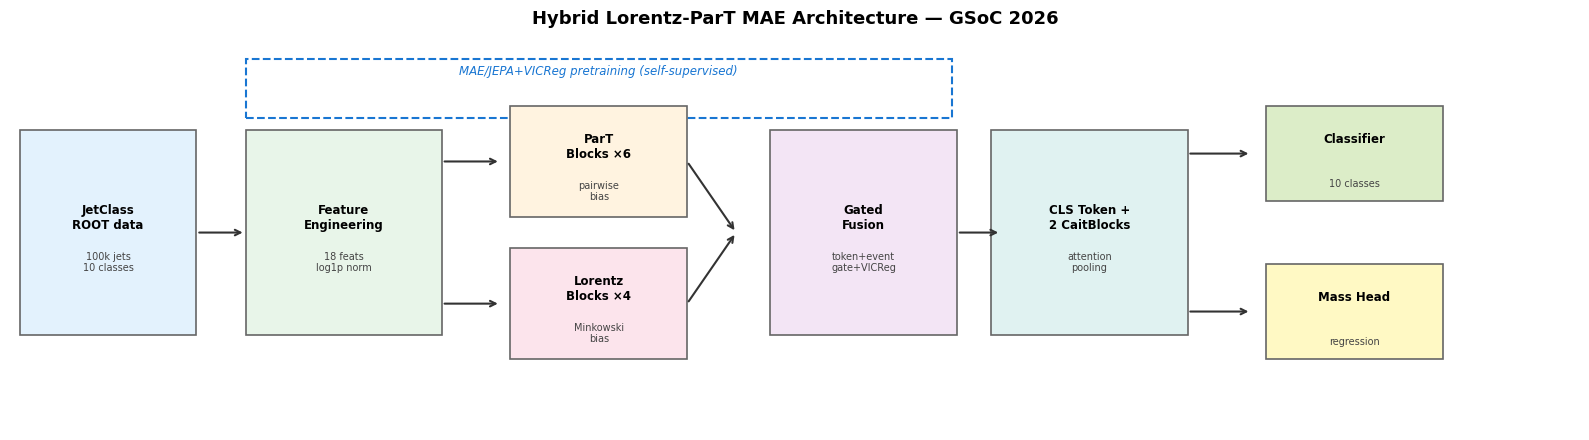

Saved: ./architecture.png


In [12]:
def plot_architecture_diagram():
    """Draw the hybrid model pipeline."""
    fig, ax = plt.subplots(figsize=(16, 4.5))
    ax.set_xlim(0, 16); ax.set_ylim(0, 5); ax.axis('off')

    boxes = [
        (1.0, 2.5, 1.8, 2.6, 'JetClass\nROOT data', '100k jets\n10 classes',    '#E3F2FD'),
        (3.4, 2.5, 2.0, 2.6, 'Feature\nEngineering', '18 feats\nlog1p norm',    '#E8F5E9'),
        (6.0, 3.4, 1.8, 1.4, 'ParT\nBlocks Ã—6',     'pairwise\nbias',          '#FFF3E0'),
        (6.0, 1.6, 1.8, 1.4, 'Lorentz\nBlocks Ã—4',  'Minkowski\nbias',         '#FCE4EC'),
        (8.7, 2.5, 1.9, 2.6, 'Gated\nFusion',       'token+event\ngate+VICReg','#F3E5F5'),
        (11.0,2.5, 2.0, 2.6, 'CLS Token +\n2 CaitBlocks','attention\npooling', '#E0F2F1'),
        (13.7,3.5, 1.8, 1.2, 'Classifier',           '10 classes',              '#DCEDC8'),
        (13.7,1.5, 1.8, 1.2, 'Mass Head',            'regression',              '#FFF9C4'),
    ]
    for xc, yc, w, h, lbl, sub, col in boxes:
        ax.add_patch(plt.Rectangle((xc-w/2, yc-h/2), w, h,
                     facecolor=col, edgecolor='#666', lw=1.2, zorder=2))
        ax.text(xc, yc+0.18, lbl, ha='center', va='center', fontsize=8.5, fontweight='bold', zorder=3)
        ax.text(xc, yc-0.38, sub, ha='center', va='center', fontsize=7,   color='#444',       zorder=3)

    arrows = [(1.9,2.5,0.5,0),(4.4,3.4,0.6,0),(4.4,1.6,0.6,0),
              (6.9,3.4,0.5,-0.9),(6.9,1.6,0.5,0.9),(9.65,2.5,0.45,0),
              (12.0,3.5,0.65,0),(12.0,1.5,0.65,0)]
    for x,y,dx,dy in arrows:
        ax.annotate('', xy=(x+dx,y+dy), xytext=(x,y),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=1.5), zorder=4)

    # SSL pretraining bracket
    ax.add_patch(plt.Rectangle((2.4, 3.95), 7.2, 0.75, facecolor='none',
                                edgecolor='#1976D2', lw=1.5, ls='--', zorder=1))
    ax.text(6.0, 4.5, 'MAE/JEPA+VICReg pretraining (self-supervised)',
            ha='center', fontsize=8.5, color='#1976D2', style='italic')

    ax.set_title('Hybrid Lorentz-ParT MAE Architecture â€” GSoC 2026',
                 fontsize=13, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.savefig('./architecture.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: ./architecture.png')

plot_architecture_diagram()


In [13]:
class ParticleFeatureEmbed(nn.Module):
    """Embed per-particle features."""
    def __init__(self, in_dim: int, d: int, drop: float):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)

class PairwiseFeatureEncoder(nn.Module):
    """Map pairwise features -> attention bias per head."""
    def __init__(self, in_dim: int, heads: int):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 32), nn.GELU(), nn.Linear(32, heads))
    def forward(self, pair):
        return self.proj(pair).permute(0,3,1,2).contiguous()


In [14]:
class ParTAttentionBlock(nn.Module):
    """ParT block with pairwise attention bias and learned interaction gating."""
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1,
                 gate_strength: float = 1.0):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)
        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

        # Interaction gate controls how strongly pairwise bias modifies attention.
        self.gate_strength = gate_strength
        self.interaction_gate_bias = nn.Parameter(torch.zeros(1, heads, 1, 1))

    def forward(self, x, mask, pair_bias):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)

        attn = (q @ k.transpose(-2,-1)) * self.scale
        if pair_bias is not None:
            gate = torch.sigmoid(self.gate_strength * pair_bias + self.interaction_gate_bias)
            attn = attn + gate * pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B, N, D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [15]:
class LightweightLorentzBlock(nn.Module):
    """L-GATr-inspired lightweight Lorentz-aware token mixer.

    Approximation note: this is not full geometric-algebra L-GATr;
    it uses four-vector invariants and Minkowski inner-product biases.
    """
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)

        self.inv_proj = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))

        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - (a[...,1]*b[...,1] + a[...,2]*b[...,2] + a[...,3]*b[...,3])

    def lorentz_bias(self, p4, mask, eps: float = 1e-8):
        pi, pj = p4.unsqueeze(2), p4.unsqueeze(1)
        md = self.mdot(pi, pj)
        mi2 = self.mdot(pi, pi)
        mj2 = self.mdot(pj, pj)
        sij = self.mdot(pi+pj, pi+pj)

        feats = torch.stack([
            torch.log(torch.clamp(md.abs(), min=eps)),
            torch.log(torch.clamp(0.5*(mi2.abs()+mj2.abs()), min=eps)),
            torch.log(torch.clamp(sij.abs(), min=eps)),
        ], dim=-1)
        bias = self.inv_proj(feats).permute(0,3,1,2).contiguous()
        valid = (mask.unsqueeze(2)*mask.unsqueeze(1)).unsqueeze(1)
        return bias * valid

    def forward(self, x, p4, mask, precomputed_bias=None):
        """SPEED FIX: accepts precomputed_bias so Lorentz invariants are
        computed once in encode() and reused across all Lorentz blocks,
        rather than recomputing the O(NÂ²) Minkowski products 4 times."""
        B, N, D = x.shape
        lbias = precomputed_bias if precomputed_bias is not None else self.lorentz_bias(p4, mask)
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale + lbias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B,N,D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [16]:
class HybridGatedFusion(nn.Module):
    """Learned fusion gate between ParT and Lorentz branches."""
    def __init__(self, d: int, token_gate: bool = True, event_gate: bool = True):
        super().__init__()
        self.token_gate = token_gate
        self.event_gate = event_gate
        if token_gate:
            self.gtok = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        if event_gate:
            self.gevt = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1), nn.Sigmoid())

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def forward(self, xp, xl, mask):
        c = torch.cat([xp, xl], dim=-1)
        gtok = self.gtok(c) if self.token_gate else torch.full_like(xp, 0.5)
        fused = gtok * xp + (1-gtok) * xl

        if self.event_gate:
            ep = self.masked_mean(xp, mask)
            el = self.masked_mean(xl, mask)
            ge = self.gevt(torch.cat([ep, el], dim=-1))
            fused = ge.unsqueeze(-1)*fused + (1-ge.unsqueeze(-1))*0.5*(xp+xl)
        else:
            ge = torch.full((xp.shape[0],1), 0.5, device=xp.device)

        return fused * mask.unsqueeze(-1), gtok, ge


In [17]:
class MaskedDecoderHead(nn.Module):
    """Decode masked particle features â€” excludes valid_mask from targets."""
    def __init__(self, d: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d), nn.GELU(),
            nn.Linear(d, out_dim)
        )
    def forward(self, x):
        return self.net(x)


class ClassAttentionBlock(nn.Module):
    """CaiT-style class attention block (ParT paper Section 4).

    WHY THIS MATTERS: Simple masked_mean pooling averages all particle
    representations equally â€” it cannot learn 'which particles matter most
    for this jet class'. The class token, by contrast, learns through
    dedicated cross-attention to focus on the most discriminating particles.
    For example, for tâ†’bâ„“Î½ tagging it learns to attend to the lepton token;
    for Hâ†’bb it learns to attend to displaced-track particles.

    Only the class token is updated here; particle tokens are frozen
    (they were already processed by the particle-attention blocks).
    """
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1_cls  = nn.LayerNorm(d)
        self.n1_part = nn.LayerNorm(d)
        self.q_proj   = nn.Linear(d, d)
        self.kv_proj  = nn.Linear(d, 2 * d)
        self.out_proj = nn.Linear(d, d)
        self.n2  = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, d),
        )
        self.drop = nn.Dropout(drop)

    def forward(self, x_class: torch.Tensor,
                x_particles: torch.Tensor,
                mask: torch.Tensor) -> torch.Tensor:
        """
        x_class     : (B, D)  â€” class token
        x_particles : (B, N, D) â€” particle embeddings (frozen)
        mask        : (B, N)  â€” valid particle mask (1=real, 0=pad)
        Returns     : (B, D)  â€” updated class token
        """
        B, N, D = x_particles.shape

        # Normalise
        xc_n = self.n1_cls(x_class).unsqueeze(1)       # (B, 1, D)
        xp_n = self.n1_part(x_particles)                # (B, N, D)

        # Q from class token only; K, V from [cls | particles]
        Q  = self.q_proj(xc_n).reshape(B, 1, self.h, self.dh).permute(0, 2, 1, 3)
        z  = torch.cat([xc_n, xp_n], dim=1)             # (B, N+1, D)
        KV = self.kv_proj(z).reshape(B, N + 1, 2, self.h, self.dh)
        K  = KV[:, :, 0].permute(0, 2, 1, 3)
        V  = KV[:, :, 1].permute(0, 2, 1, 3)

        attn = (Q @ K.transpose(-2, -1)) * self.scale    # (B, H, 1, N+1)

        # cls token is always valid; then apply particle validity mask
        cls_valid  = torch.ones(B, 1, device=mask.device)
        full_valid = torch.cat([cls_valid, mask], dim=1)  # (B, N+1)
        attn = attn.masked_fill(
            ~(full_valid.unsqueeze(1).unsqueeze(2) > 0.5),
            torch.finfo(attn.dtype).min,
        )
        attn = torch.softmax(attn, dim=-1)

        out = (attn @ V).squeeze(2).reshape(B, D)         # (B, D)

        # Residual connections (pre-norm style)
        x_class = x_class + self.drop(self.out_proj(out))
        x_class = x_class + self.drop(self.mlp(self.n2(x_class)))
        return x_class


class ClassificationHead(nn.Module):
    """Event-level classifier MLP (takes CLS token as input)."""
    def __init__(self, d: int, ncls: int, drop: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.net  = nn.Sequential(
            nn.Linear(d, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d // 2, ncls),
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(self.norm(z))


class OptionalMassRegressionHead(nn.Module):
    """Optional event mass regressor."""
    def __init__(self, d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d // 2), nn.GELU(),
            nn.Linear(d // 2, 1),
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z).squeeze(-1)


In [18]:
class HybridLorentzParTMAE(nn.Module):
    """Hybrid ParT + Lorentz MAE â€” GSoC 2026 v2.

    Key architectural changes vs v1
    â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    1. Input features: 9 â†’ 18  (particle-ID + trajectory displacement added)
    2. Encoder depth: 4+3 â†’ 6+4  (deeper = richer representations)
    3. Pooling: masked_mean â†’ learnable CLS token + 2 ClassAttentionBlocks
       The CLS token learns to focus on discriminating particles rather than
       averaging everything equally (matches ParT paper Section 4).
    4. Reconstruction: excludes valid_mask from decoder target (trivial feature).
    """
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg  = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d   = cfg.EMBED_DIM

        # â”€â”€ Embedding â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        self.embed = ParticleFeatureEmbed(fin, d, cfg.DROPOUT)
        self.penc  = PairwiseFeatureEncoder(len(cfg.PAIRWISE_FEATURES), cfg.NUM_HEADS)

        # â”€â”€ Particle-level encoder (two independent branches) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        self.part = nn.ModuleList([
            ParTAttentionBlock(
                d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT,
                gate_strength=cfg.ATTN_INTERACTION_GATE_STRENGTH,
            )
            for _ in range(max(cfg.NUM_LAYERS_PART, 1))
        ])
        self.lor  = nn.ModuleList([
            LightweightLorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT)
            for _ in range(max(cfg.NUM_LAYERS_LORENTZ, 1))
        ])

        # â”€â”€ Hybrid gated fusion â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        self.fusion = HybridGatedFusion(d, cfg.USE_TOKEN_GATE, cfg.USE_EVENT_GATE)

        # â”€â”€ CLS token + class-attention pooling (replaces masked_mean) â”€â”€â”€
        # Learnable initial CLS token, one per event (broadcast from (1, D))
        self.cls_token = nn.Parameter(torch.zeros(1, d))
        nn.init.trunc_normal_(self.cls_token, std=0.02)  # standard ViT init

        num_cls = getattr(cfg, 'NUM_CLS_BLOCKS', 2)
        self.cls_blocks = nn.ModuleList([
            ClassAttentionBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT)
            for _ in range(num_cls)
        ])

        # â”€â”€ Output heads â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        # Decoder reconstructs kinematic+ID features but NOT valid_mask
        # (valid_mask = trivially 1 for all real particles; no learning value)
        reco_dim = fin - 1  # exclude valid_mask (always the last feature)
        self.dec  = MaskedDecoderHead(d, reco_dim)
        self.cls  = ClassificationHead(d, cfg.NUM_CLASSES, cfg.DROPOUT)
        self.mass = OptionalMassRegressionHead(d)

    # ------------------------------------------------------------------
    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def _pool(self, hf: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """Pool particle tokens â†’ event vector via CLS-token class attention."""
        B = hf.size(0)
        cls = self.cls_token.expand(B, -1)      # (B, D)
        for blk in self.cls_blocks:
            cls = blk(cls, hf, mask)
        return cls                               # (B, D)

    def encode(self, x, p4, mask):
        h0    = self.embed(x) * mask.unsqueeze(-1)
        pair  = compute_pairwise_features_from_p4(p4, mask)
        pbias = self.penc(pair)

        hp = h0
        for blk in self.part[:self.cfg.NUM_LAYERS_PART]:
            hp = blk(hp, mask, pbias)

        # SPEED FIX: compute Lorentz bias ONCE and share across all Lorentz blocks.
        # lorentz_bias() does 4Ã— O(NÂ²) Minkowski inner products.
        # Without this, it runs once per block = 4Ã— redundant computation.
        lor_bias = self.lor[0].lorentz_bias(p4, mask) if self.cfg.NUM_LAYERS_LORENTZ > 0 else None
        hl = h0
        for blk in self.lor[:self.cfg.NUM_LAYERS_LORENTZ]:
            hl = blk(hl, p4, mask, precomputed_bias=lor_bias)

        return hp, hl

    def forward(self, x, p4, mask, mode: str = 'finetune'):
        hp, hl = self.encode(x, p4, mask)
        hf, gtok, gevt = self.fusion(hp, hl, mask)

        # CLS-token pooling for classification / regression heads
        pooled = self._pool(hf, mask)

        out = {
            'logits':    self.cls(pooled),
            'mass_pred': self.mass(pooled),
            # Decoder operates on particle tokens (not CLS);
            # outputs reco_dim = fin-1 features (no valid_mask)
            'reco':      self.dec(hf),
            'g_tok':     gtok,
            'g_evt':     gevt,
        }
        if mode == 'pretrain':
            return {'reco': out['reco'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'finetune':
            return {'logits': out['logits'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'multitask':
            return out
        raise ValueError(f'Unknown mode: {mode}')

## SECTION 8 â€” LOSS FUNCTIONS


In [19]:
# --- Feature index helpers ------------------------------------------------
PHI_FEAT_NAME = 'phi'   # name of phi in PER_PARTICLE_FEATURES


def _phi_idx(feat_names):
    try:
        return list(feat_names).index(PHI_FEAT_NAME)
    except ValueError:
        return None


def build_reco_feature_weights(cfg, feat_idx: Dict[str, int], reco_dim: int,
                               device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    """Build per-feature reconstruction weights (physics-informed defaults)."""
    w = torch.full((reco_dim,), float(cfg.RECO_WEIGHT_DEFAULT), device=device, dtype=dtype)
    named = {
        'pt': cfg.RECO_WEIGHT_PT,
        'eta': cfg.RECO_WEIGHT_ETA,
        'phi': cfg.RECO_WEIGHT_PHI,
        'E': cfg.RECO_WEIGHT_E,
    }
    for name, val in named.items():
        idx = feat_idx.get(name, None)
        if idx is not None and idx < reco_dim:
            w[idx] = float(val)
    return w


def masked_reco_loss(reco: torch.Tensor, target: torch.Tensor,
                     masked_token_indicator: torch.Tensor,
                     phi_feat_idx: Optional[int] = None,
                     feature_weights: Optional[torch.Tensor] = None) -> torch.Tensor:
    """Smooth-L1 over masked tokens with phi circular correction and feature weights."""
    # Strip valid_mask column (always last) from target to match decoder output.
    reco_dim = reco.shape[-1]
    target   = target[..., :reco_dim]   # (B, N, reco_dim)

    w = masked_token_indicator.unsqueeze(-1).float()
    n_feat = reco.shape[-1]

    if feature_weights is None:
        feature_weights = torch.ones((n_feat,), device=reco.device, dtype=reco.dtype)
    feature_weights = feature_weights.view(1, 1, n_feat)

    # Smooth-L1 on all features with physics-informed weighting.
    smooth_l1 = F.smooth_l1_loss(reco * w, target * w, reduction='none')
    loss_total = (smooth_l1 * w * feature_weights).sum() / w.sum().clamp_min(1.0)

    # Override phi contribution with circular loss.
    if phi_feat_idx is not None and phi_feat_idx < n_feat:
        phi_pred = reco[..., phi_feat_idx]
        phi_true = target[..., phi_feat_idx]
        phi_mask = masked_token_indicator.float()
        cos_loss = (1.0 - (torch.cos(phi_true) * torch.cos(phi_pred)
                           + torch.sin(phi_true) * torch.sin(phi_pred)))
        phi_weight = feature_weights[..., phi_feat_idx]
        phi_term = ((cos_loss * phi_mask) * phi_weight).sum() / phi_mask.sum().clamp_min(1.0)

        phi_mse = ((smooth_l1[..., phi_feat_idx] * phi_mask) * phi_weight).sum() / phi_mask.sum().clamp_min(1.0)
        loss_total = loss_total - phi_mse + phi_term

    return loss_total


def conservation_loss(reco: torch.Tensor, target: torch.Tensor,
                      masked_token_indicator: torch.Tensor,
                      feat_idx: Dict[str, int]) -> torch.Tensor:
    """Compare masked momentum sums and masked invariant-mass proxy."""
    iE  = feat_idx['E']
    ipx = feat_idx['px']
    ipy = feat_idx['py']
    ipz = feat_idx['pz']
    m = masked_token_indicator.float()

    def _sum4(arr):
        return torch.stack([
            (arr[..., iE]  * m).sum(1),
            (arr[..., ipx] * m).sum(1),
            (arr[..., ipy] * m).sum(1),
            (arr[..., ipz] * m).sum(1),
        ], dim=-1)

    pred4 = _sum4(reco)
    true4 = _sum4(target)

    lp4 = F.smooth_l1_loss(pred4, true4)
    pm2 = pred4[:, 0]**2 - (pred4[:, 1]**2 + pred4[:, 2]**2 + pred4[:, 3]**2)
    tm2 = true4[:, 0]**2 - (true4[:, 1]**2 + true4[:, 2]**2 + true4[:, 3]**2)
    lm  = F.smooth_l1_loss(torch.clamp(pm2, min=0.0), torch.clamp(tm2, min=0.0))
    return lp4 + 0.5 * lm


class FocalLoss(nn.Module):
    """Focal loss â€” down-weights easy examples."""
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction='none',
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def gate_regularization(out: Dict[str, torch.Tensor], weight: float) -> torch.Tensor:
    """Prevent gate saturation via two terms:
    1. Mean-centering: pushes global mean toward 0.5
    2. Entropy: rewards gates that vary (penalises constant gates)

    FIX 2: original only penalised mean deviation. With only that term the
    gate can saturate to a constant value near 0.5 globally while individual
    events are still 0 or 1. Added entropy term prevents this.
    Observed before fix: event_gate mean=0.72 (sat. at ParT), token_gate=0.33.
    """
    if weight <= 0.0 or 'g_evt' not in out:
        return torch.tensor(0.0, device=out['reco'].device if 'reco' in out else out['logits'].device)
    device = out['g_evt'].device
    ge = out['g_evt']  # (B, 1)
    # Term 1: mean centering (original)
    mean_reg = torch.abs(ge.mean() - 0.5)
    # Term 2: entropy bonus â€” p*log(p) + (1-p)*log(1-p), maximised at p=0.5
    eps = 1e-6
    entropy = -(ge * torch.log(ge + eps) + (1 - ge) * torch.log(1 - ge + eps)).mean()
    # entropy is maximised (~0.693) at 0.5; subtract it (we want to maximise entropy)
    entropy_reg = 0.693 - entropy  # penalise deviation from max entropy
    return weight * (mean_reg + 0.5 * entropy_reg)


def pretrain_total_loss(out, target_x, masked_token_indicator, cfg, feat_idx):
    """Weighted pretraining loss with optional VICReg on JEPA embeddings."""
    """Weighted pretraining loss with phi circular correction + gate regularization."""
    phi_idx = feat_idx.get('phi', None)
    reco_weights = None
    if getattr(cfg, 'USE_PHYSICS_RECO_WEIGHTING', False):
        reco_weights = build_reco_feature_weights(
            cfg, feat_idx, out['reco'].shape[-1],
            device=out['reco'].device, dtype=out['reco'].dtype,
        )

    lr = masked_reco_loss(
        out['reco'], target_x, masked_token_indicator,
        phi_feat_idx=phi_idx, feature_weights=reco_weights,
    )
    lc = conservation_loss(out['reco'], target_x, masked_token_indicator, feat_idx)
    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = cfg.W_RECO * lr + cfg.W_CONS * lc + lgate

    # VICReg on JEPA predictions to prevent embedding collapse
    vicreg_val = torch.tensor(0.0, device=total.device)
    if getattr(cfg, 'USE_JEPA_PRETRAIN', False) and 'jepa_pred' in out:
        pred_flat = out['jepa_pred'].reshape(-1, out['jepa_pred'].shape[-1])
        if pred_flat.shape[0] > 1:
            vicreg_val = vicreg_loss(pred_flat.float())
            total = total + 0.05 * vicreg_val  # stabilises JEPA without dominating

    return total, {'reco': lr.item(), 'cons': lc.item(),
                   'jepa': vicreg_val.item(),
                   'gate_reg': float(lgate.item())}


def finetune_total_loss(out, batch, cfg, focal=False,
                        class_weights: Optional[torch.Tensor] = None):
    """Weighted finetune/multitask loss with label smoothing + gate regularization."""
    if focal:
        lcls = FocalLoss(label_smoothing=cfg.LABEL_SMOOTHING)(
            out['logits'], batch['y'])
    else:
        lcls = F.cross_entropy(
            out['logits'], batch['y'],
            weight=class_weights,
            label_smoothing=cfg.LABEL_SMOOTHING,
        )
    total = cfg.W_CLASS * lcls
    logs  = {'cls': lcls.item()}

    if cfg.USE_AUX_MASS and 'mass_pred' in out:
        lm = F.smooth_l1_loss(out['mass_pred'], batch['mass'])
        total = total + cfg.AUX_MASS_WEIGHT * lm
        logs['mass'] = lm.item()

    lgate = gate_regularization(out, cfg.GATE_REG_WEIGHT)
    total = total + lgate
    logs['gate_reg'] = float(lgate.item())

    return total, logs

## SECTION 9 â€” TRAINING UTILITIES


In [20]:
class AverageMeter:
    """Running average meter."""
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    """Simple early stopping utility."""
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    """Build AdamW optimizer.

    Improvement: during fine-tuning, use differential learning rates â€”
    the pretrained backbone gets a 10x smaller LR than the classification
    head, which is the standard practice when transferring pretrained weights
    (matches the approach in the ParT paper's fine-tuning protocol).
    """
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

    # Separate backbone params from head params
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup then cosine annealing.

    Improvement over plain CosineAnnealingLR: transformers benefit from
    a warm-up phase to stabilise the large Lorentz-equivariant linear maps
    before the cosine decay kicks in.
    """
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    """Cosine scheduler with linear warmup."""
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    """Save checkpoint."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    """Load checkpoint."""
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    """Move batch to target device."""
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


In [21]:
class JEPAPretrainer(nn.Module):
    """JEPA helper with EMA target model for masked-token representation prediction."""
    def __init__(self, online_model: HybridLorentzParTMAE, ema_decay: float = 0.996):
        super().__init__()
        self.online_model = online_model
        self.target_model = copy.deepcopy(online_model).eval()
        for p in self.target_model.parameters():
            p.requires_grad_(False)

        d = online_model.cfg.EMBED_DIM
        self.predictor = nn.Sequential(
            nn.Linear(d, d // 2),
            nn.LayerNorm(d // 2),
            nn.GELU(),
            nn.Linear(d // 2, d),
        )
        self.ema_decay = ema_decay

    @torch.no_grad()
    def update_target(self):
        for p_o, p_t in zip(self.online_model.parameters(), self.target_model.parameters()):
            p_t.data.mul_(self.ema_decay).add_(p_o.data, alpha=1.0 - self.ema_decay)

    def forward(self, x_masked, x_full, p4, mask, masked_token_indicator):
        hp_o, hl_o = self.online_model.encode(x_masked, p4, mask)
        hf_o, _, _ = self.online_model.fusion(hp_o, hl_o, mask)
        pred = self.predictor(hf_o)

        with torch.no_grad():
            hp_t, hl_t = self.target_model.encode(x_full, p4, mask)
            hf_t, _, _ = self.target_model.fusion(hp_t, hl_t, mask)
            tgt = F.layer_norm(hf_t, hf_t.shape[-1:])

        m = masked_token_indicator.bool()
        if m.any():
            return F.smooth_l1_loss(pred[m], tgt[m])
        return torch.tensor(0.0, device=pred.device, dtype=pred.dtype)


class AverageMeter:
    """Running average meter."""
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    """Simple early stopping utility."""
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    """Build AdamW optimizer.

    Improvement: during fine-tuning, use differential learning rates â€”
    the pretrained backbone gets a 10x smaller LR than the classification
    head, which is the standard practice when transferring pretrained weights
    (matches the approach in the ParT paper's fine-tuning protocol).
    """
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

    # Separate backbone params from head params
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup then cosine annealing.

    Improvement over plain CosineAnnealingLR: transformers benefit from
    a warm-up phase to stabilise the large Lorentz-equivariant linear maps
    before the cosine decay kicks in.
    """
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    """Cosine scheduler with linear warmup."""
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    """Save checkpoint."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    """Load checkpoint."""
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    """Move batch to target device."""
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def train_epoch_pretrain(model, loader, opt, amp_scaler, device, cfg, feat_idx,
                         jepa_helper: Optional[JEPAPretrainer] = None):
    """One pretraining epoch with optional biased masking and JEPA objective."""
    model.train()
    lm, lr, lc, lv, lj = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Pretrain', leave=False):
        batch = to_device(batch, device)
        vis_x, target_x, reco_mask, _ = build_mae_targets(
            batch['x'], batch['p4'], batch['mask'],
            cfg.MASK_RATIO,
            biased=cfg.USE_BIASED_MASK)
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(vis_x, batch['p4'], batch['mask'], mode='pretrain')
            loss_mae, logs = pretrain_total_loss(out, target_x, reco_mask, cfg, feat_idx)
            loss = loss_mae

            jepa_val = torch.tensor(0.0, device=loss_mae.device)
            use_jepa = bool(getattr(cfg, 'USE_JEPA_PRETRAIN', False)) and (jepa_helper is not None)
            if use_jepa:
                jepa_val = jepa_helper(vis_x, batch['x'], batch['p4'], batch['mask'], reco_mask)
                loss = loss + float(getattr(cfg, 'JEPA_WEIGHT', 0.0)) * jepa_val
                logs['jepa'] = float(jepa_val.item())
            else:
                logs['jepa'] = 0.0

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        if bool(getattr(cfg, 'USE_JEPA_PRETRAIN', False)) and (jepa_helper is not None):
            jepa_helper.update_target()

        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz)
        lr.update(logs['reco'], bsz)
        lc.update(logs['cons'], bsz)
        lv.update(logs.get('vicreg', 0.0), bsz)
        lj.update(logs['jepa'], bsz)

    return {'loss': lm.avg, 'reco': lr.avg, 'cons': lc.avg, 'vicreg': lv.avg, 'jepa': lj.avg,
            'time': time.time() - t0}


def train_epoch_finetune(model, loader, opt, amp_scaler, device, cfg,
                         class_weights: Optional[torch.Tensor] = None):
    """One fine-tuning epoch."""
    model.train()
    lm, am = AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Finetune', leave=False):
        batch = to_device(batch, device)
        opt.zero_grad(set_to_none=True)

        mode = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
            loss, _ = finetune_total_loss(out, batch, cfg,
                                          class_weights=class_weights)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        pred = out['logits'].argmax(1)
        acc  = (pred == batch['y']).float().mean().item()
        bsz  = batch['x'].size(0)
        lm.update(loss.item(), bsz); am.update(acc, bsz)

    return {'loss': lm.avg, 'acc': am.avg, 'time': time.time() - t0}


@torch.no_grad()
def eval_finetune(model, loader, device, cfg):
    """Evaluate classifier and optional mass regressor."""
    model.eval()
    Y, P, YH, MT, MP = [], [], [], [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = to_device(batch, device)
        mode  = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        out   = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
        prob  = torch.softmax(out['logits'], dim=1)
        yhat  = prob.argmax(1)
        Y.append(batch['y'].cpu().numpy())
        P.append(prob.cpu().numpy())
        YH.append(yhat.cpu().numpy())
        MT.append(batch['mass'].cpu().numpy())
        if 'mass_pred' in out:
            MP.append(out['mass_pred'].cpu().numpy())

    y = np.concatenate(Y); p = np.concatenate(P); yh = np.concatenate(YH)
    met = {'accuracy': accuracy_score(y, yh)}
    try:
        met['macro_auc_ovr'] = roc_auc_score(
            y, p, multi_class='ovr', average='macro')
        met['macro_auc_ovo'] = roc_auc_score(
            y, p, multi_class='ovo', average='macro')
    except Exception:
        met['macro_auc_ovr'] = np.nan
        met['macro_auc_ovo'] = np.nan

    if len(MP):
        mt, mp = np.concatenate(MT), np.concatenate(MP)
        if getattr(cfg, 'MASS_TARGET_NORMALIZE', False):
            mass_mean = float(getattr(cfg, 'MASS_MEAN', 0.0))
            mass_std = float(getattr(cfg, 'MASS_STD', 1.0))
            mt = mt * mass_std + mass_mean
            mp = mp * mass_std + mass_mean
        met['mass_mae']  = mean_absolute_error(mt, mp)
        met['mass_rmse'] = float(np.sqrt(mean_squared_error(mt, mp)))

    return met, y, p, yh

## SECTION 10 â€” EVALUATION METRICS


In [22]:
def plot_curves(hist: Dict[str, List[float]], title: str):
    """Plot metric curves."""
    plt.figure(figsize=(8, 4))
    for k, v in hist.items():
        plt.plot(v, label=k)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Value')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


def plot_confusion(y, yh, class_names):
    """Plot normalised confusion matrix."""
    cm  = confusion_matrix(y, yh)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title in zip(axes, [cm, cmn],
                                ['Confusion Matrix (counts)',
                                 'Confusion Matrix (row-normalised)']):
        im = ax.imshow(data, cmap='Blues',
                       vmin=0, vmax=(None if 'counts' in title else 1))
        ax.set_title(title)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_rocs(y, p, class_names):
    """Plot per-class one-vs-rest ROC curves with AUC in legend."""
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(C):
        try:
            fpr, tpr, _ = roc_curve(yoh[:, i], p[:, i])
            ax.plot(fpr, tpr,
                    label=f'{class_names[i]}  AUC={auc(fpr, tpr):.3f}')
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title('Per-class ROC curves (one-vs-rest)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def bkg_rej_at_sig_eff(y: np.ndarray, p: np.ndarray,
                        sig_class: int = 0, eff: float = 0.5) -> float:
    """Background rejection 1/FPR at fixed signal efficiency (TPR=eff).

    This is the standard HEP metric (Rej50%) used in both the ParT paper
    (Table 1) and the L-GATr paper (Table 1).
    """
    yb = (y == sig_class).astype(int)
    fpr, tpr, _ = roc_curve(yb, p[:, sig_class])
    i = np.argmin(np.abs(tpr - eff))
    return float(1.0 / max(fpr[i], 1e-8))


def compute_per_class_metrics(y: np.ndarray, p: np.ndarray,
                               class_names: List[str],
                               cfg) -> pd.DataFrame:
    """Compute per-class AUC and background rejection at multiple efficiencies.

    Improvement: produces the same table format as Table 1 in the ParT paper
    (Qu et al. 2022) for direct comparison â€” per-class AUC and Rej50%/Rej99%.
    """
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    rows = []

    # Identify "easy" classes that use Rej99% threshold
    high_eff_classes = set()  # add class names here if known, e.g. {'Hltqq','tbln'}

    for i, name in enumerate(class_names):
        row = {'class': name}
        try:
            fpr_i, tpr_i, _ = roc_curve(yoh[:, i], p[:, i])
            row['AUC'] = float(auc(fpr_i, tpr_i))
        except Exception:
            row['AUC'] = float('nan')

        for sig_eff, label in [(0.50, 'Rej50%'), (0.30, 'Rej30%'),
                                (0.99, 'Rej99%'), (0.995, 'Rej99.5%')]:
            try:
                row[label] = bkg_rej_at_sig_eff(y, p, sig_class=i, eff=sig_eff)
            except Exception:
                row[label] = float('nan')

        rows.append(row)

    df = pd.DataFrame(rows).set_index('class')
    return df


def print_physics_summary(test_metrics: dict, y: np.ndarray,
                           p: np.ndarray, class_names: List[str], cfg):
    """Print full physics-style evaluation table matching paper format."""
    print("=" * 60)
    print(f"  Overall accuracy : {test_metrics['accuracy']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovr', np.nan)):
        print(f"  Macro AUC (OvR) : {test_metrics['macro_auc_ovr']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovo', np.nan)):
        print(f"  Macro AUC (OvO) : {test_metrics['macro_auc_ovo']:.4f}")
    if 'mass_mae' in test_metrics:
        print(f"  Mass MAE        : {test_metrics['mass_mae']:.4f}")
        print(f"  Mass RMSE       : {test_metrics['mass_rmse']:.4f}")
    print("=" * 60)

    df = compute_per_class_metrics(y, p, class_names, cfg)
    print("\nPer-class metrics (ParT-paper Table 1 format):")
    print(df.to_string(float_format=lambda x: f"{x:8.1f}" if x > 1 else f"{x:.4f}"))
    return df


## SECTION 11 â€” PRETRAINING RUN


In [23]:
train_loader, val_loader, test_loader, meta = build_loaders(cfg)
class_names   = meta['classes']
class_weights = torch.tensor(meta['class_weights'], dtype=torch.float32, device=device)
if not cfg.USE_CLASS_WEIGHTS:
    class_weights = None

print('Classes:', class_names)
print('Batches train/val/test:',
      len(train_loader), len(val_loader), len(test_loader))
if class_weights is not None:
    print('Class weights:', class_weights.detach().cpu().numpy())

model    = HybridLorentzParTMAE(cfg).to(device)
model    = maybe_compile(model)  # torch.compile: ~1.4x speedup
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

opt      = make_optimizer(model, cfg)   # pretrain: all params same LR
sch      = make_scheduler(opt, cfg.PRETRAIN_EPOCHS,
                          warmup_epochs=cfg.WARMUP_EPOCHS)   # <â”€â”€ warmup
amp_scaler = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
feat_idx = {k: i for i, k in enumerate(cfg.PER_PARTICLE_FEATURES)}

jepa_helper = None
if cfg.USE_JEPA_PRETRAIN:
    jepa_helper = JEPAPretrainer(model, ema_decay=cfg.JEPA_EMA_DECAY).to(device)
    print(f"[INFO] JEPA enabled: weight={cfg.JEPA_WEIGHT:.3f}, ema_decay={cfg.JEPA_EMA_DECAY:.4f}")

pre_hist = {'loss': [], 'reco': [], 'cons': [], 'jepa': [], 'lr': []}
for ep in range(cfg.PRETRAIN_EPOCHS):
    logs = train_epoch_pretrain(model, train_loader, opt, amp_scaler,
                                device, cfg, feat_idx,
                                jepa_helper=jepa_helper)
    current_lr = sch.get_last_lr()[0]
    sch.step()
    pre_hist['loss'].append(logs['loss'])
    pre_hist['reco'].append(logs['reco'])
    pre_hist['cons'].append(logs['cons'])
    pre_hist['jepa'].append(logs.get('jepa', 0.0))
    pre_hist['lr'].append(current_lr)
    print(f"[Pretrain {ep+1:2d}/{cfg.PRETRAIN_EPOCHS}]"
          f"  loss={logs['loss']:.4f}"
          f"  reco={logs['reco']:.4f}"
          f"  cons={logs['cons']:.4f}"
          f"  jepa={logs.get('jepa', 0.0):.4f}"
          f"  lr={current_lr:.2e}"
          f"  t={logs['time']:.1f}s")

Reading ROOT:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] progress files=10/100 seen_events=25000 kept_samples=25000
[INFO] progress files=20/100 seen_events=50000 kept_samples=50000
[INFO] progress files=30/100 seen_events=75000 kept_samples=75000
[INFO] progress files=40/100 seen_events=100000 kept_samples=100000
[INFO] progress files=50/100 seen_events=125000 kept_samples=100000
[INFO] progress files=60/100 seen_events=150000 kept_samples=100000
[INFO] progress files=70/100 seen_events=175000 kept_samples=100000
[INFO] progress files=80/100 seen_events=200000 kept_samples=100000
[INFO] progress files=90/100 seen_events=225000 kept_samples=100000
[INFO] progress files=100/100 seen_events=250000 kept_samples=100000
[INFO] Total loaded events: 250000
[INFO] Sampled events: 100000 (target=100000)
[INFO] Split counts train/val/test = 80000/10000/10000
[INFO] Split ratios train/val/test = 0.800/0.100/0.100
[INFO] Mass target normalization: mean=113.9527, std=37.4831
Classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TT

Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain  1/20]  loss=3.4579  reco=2.4479  cons=5.0470  jepa=0.0000  lr=1.00e-04  t=156.3s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Pretrain 18/20]  loss=0.5607  reco=0.5041  cons=0.2828  jepa=0.0000  lr=2.52e-05  t=146.3s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain 19/20]  loss=0.5595  reco=0.5047  cons=0.2739  jepa=0.0000  lr=1.30e-05  t=145.0s


Pretrain:   0%|          | 0/625 [00:00<?, ?it/s]

[Pretrain 20/20]  loss=0.5541  reco=0.5025  cons=0.2575  jepa=0.0000  lr=5.53e-06  t=161.5s


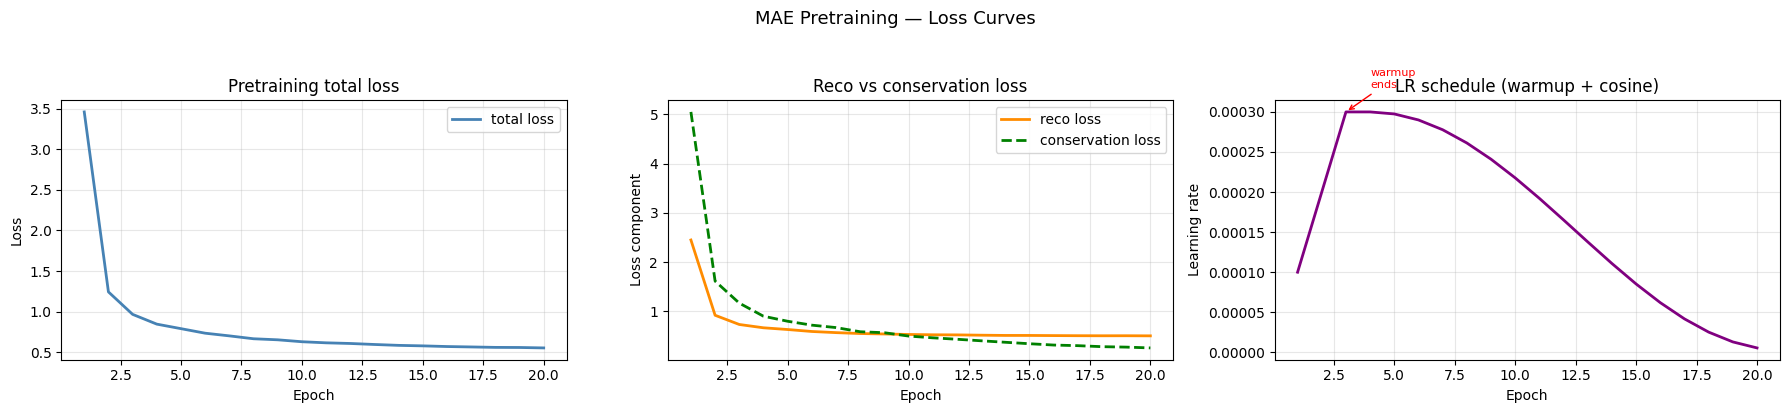

Saved: ./pretraining_curves.png
Best pretrain loss: 0.5541 at epoch 20


In [25]:
# â”€â”€ Rich pretraining visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs = range(1, len(pre_hist["loss"]) + 1)

axes[0].plot(epochs, pre_hist["loss"],  color='steelblue', lw=2, label='total loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Pretraining total loss'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, pre_hist["reco"],  color='darkorange', lw=2, label='reco loss')
axes[1].plot(epochs, pre_hist["cons"],  color='green',      lw=2, label='conservation loss', ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss component')
axes[1].set_title('Reco vs conservation loss'); axes[1].grid(alpha=0.3); axes[1].legend()

axes[2].plot(epochs, pre_hist["lr"], color='purple', lw=2)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning rate')
axes[2].set_title('LR schedule (warmup + cosine)'); axes[2].grid(alpha=0.3)
axes[2].annotate('warmup\nends', xy=(cfg.WARMUP_EPOCHS, pre_hist["lr"][cfg.WARMUP_EPOCHS-1]),
                 fontsize=8, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'),
                 xytext=(cfg.WARMUP_EPOCHS+1, pre_hist["lr"][cfg.WARMUP_EPOCHS-1]*1.1))

plt.suptitle('MAE Pretraining â€” Loss Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./pretraining_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: ./pretraining_curves.png')
print(f'Best pretrain loss: {min(pre_hist["loss"]):.4f} at epoch {pre_hist["loss"].index(min(pre_hist["loss"]))+1}')

In [26]:
@torch.no_grad()
def show_reco_examples(model, loader, cfg, n_events=2):
    """Print reconstructed vs true features for masked particles."""
    model.eval()
    batch = next(iter(loader)); batch = to_device(batch, device)
    vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
    out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

    names = list(cfg.PER_PARTICLE_FEATURES)
    for b in range(min(n_events, batch['x'].size(0))):
        idx = torch.where(rm[b])[0][:8]
        if len(idx) == 0: continue
        print(f'Event {b}, masked tokens shown: {len(idx)}')
        for fname in ['px','py','pz','E','pt']:
            j = names.index(fname)
            t = tgt[b, idx, j].detach().cpu().numpy()
            p = out['reco'][b, idx, j].detach().cpu().numpy()
            print(f'  {fname} true[:4]={np.round(t[:4],3)} pred[:4]={np.round(p[:4],3)}')

show_reco_examples(model, train_loader, cfg)


Event 0, masked tokens shown: 8
  px true[:4]=[-4.762 -1.954 -1.957 -1.811] pred[:4]=[-4.585 -1.981 -1.947 -1.833]
  py true[:4]=[4.997 2.782 2.739 2.619] pred[:4]=[5.119 2.8   2.741 2.627]
  pz true[:4]=[5.133 2.63  2.58  2.378] pred[:4]=[5.076 2.609 2.569 2.437]
  E true[:4]=[5.533 3.082 3.039 2.882] pred[:4]=[5.518 3.077 3.018 2.897]
  pt true[:4]=[5.238 2.852 2.815 2.689] pred[:4]=[5.19  2.866 2.819 2.694]
Event 1, masked tokens shown: 8
  px true[:4]=[-2.926 -2.733 -2.514 -2.447] pred[:4]=[-2.953 -2.802 -2.525 -2.456]
  py true[:4]=[3.92  3.423 3.451 3.404] pred[:4]=[3.969 3.511 3.507 3.485]
  pz true[:4]=[-3.602 -3.049 -3.126 -3.047] pred[:4]=[-3.635 -3.185 -3.17  -3.127]
  E true[:4]=[4.165 3.679 3.694 3.634] pred[:4]=[4.192 3.795 3.747 3.708]
  pt true[:4]=[3.979 3.525 3.514 3.464] pred[:4]=[4.009 3.611 3.556 3.517]


## SECTION 12 — FINE-TUNING RUN

Validation model selection uses macro AUC (OvR). If validation AUC is undefined (`NaN`) for an epoch, checkpointing and early-stopping selection fall back to validation accuracy for stability.

In [27]:
ckpt_path = Path('./checkpoints/hybrid_mae_pretrained.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_path)

ft_model = HybridLorentzParTMAE(cfg).to(device)
ft_model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)

# Differential LR: backbone gets BACKBONE_LR_FACTOR * LR, head gets LR
optf   = make_optimizer(ft_model, cfg, finetune_mode=True)   # <â”€â”€ diff LR
schf   = make_scheduler(optf, cfg.FINETUNE_EPOCHS,
                        warmup_epochs=cfg.WARMUP_EPOCHS)      # <â”€â”€ warmup
scalerf = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
early   = EarlyStopping(patience=cfg.EARLY_STOP_PATIENCE, mode='max')

best_path    = Path('./checkpoints/hybrid_mae_best_finetune.pt')
best_val_auc = -np.inf

ft_hist = {'train_loss': [], 'train_acc': [], 'val_acc': [],
           'val_auc_ovr': [], 'val_auc_ovo': [], 'lr': []}

for ep in range(cfg.FINETUNE_EPOCHS):
    tr = train_epoch_finetune(ft_model, train_loader, optf, scalerf,
                              device, cfg, class_weights=class_weights)
    va, *_ = eval_finetune(ft_model, val_loader, device, cfg)
    current_lr = schf.get_last_lr()[0]
    schf.step()

    val_auc = va['macro_auc_ovr']
    if np.isnan(val_auc):
        val_auc = va['accuracy']

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(ft_model.state_dict(), best_path)

    ft_hist['train_loss'].append(tr['loss'])
    ft_hist['train_acc'].append(tr['acc'])
    ft_hist['val_acc'].append(va['accuracy'])
    ft_hist['val_auc_ovr'].append(va['macro_auc_ovr'])
    ft_hist['val_auc_ovo'].append(va.get('macro_auc_ovo', np.nan))
    ft_hist['lr'].append(current_lr)

    print(f"[Finetune {ep+1:2d}/{cfg.FINETUNE_EPOCHS}]"
          f"  train_loss={tr['loss']:.4f}"
          f"  train_acc={tr['acc']:.4f}"
          f"  val_acc={va['accuracy']:.4f}"
          f"  val_auc={val_auc:.4f}"
          f"  lr={current_lr:.2e}")

    if early.step(val_auc):
        print(f"Early stopping at epoch {ep+1}."
              f" Best val_auc={best_val_auc:.4f}")
        break

if best_path.exists():
    ft_model.load_state_dict(
        torch.load(best_path, map_location=device), strict=False)
    print(f"Loaded best fine-tuned checkpoint (val_auc={best_val_auc:.4f})")


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune  1/35]  train_loss=2.1184  train_acc=0.2148  val_acc=0.3804  val_auc=0.8179  lr=3.00e-05


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune 34/35]  train_loss=1.1204  train_acc=0.7259  val_acc=0.6983  val_auc=0.9519  lr=1.76e-06


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

[Finetune 35/35]  train_loss=1.1179  train_acc=0.7260  val_acc=0.6970  val_auc=0.9519  lr=1.11e-06
Loaded best fine-tuned checkpoint (val_auc=0.9525)


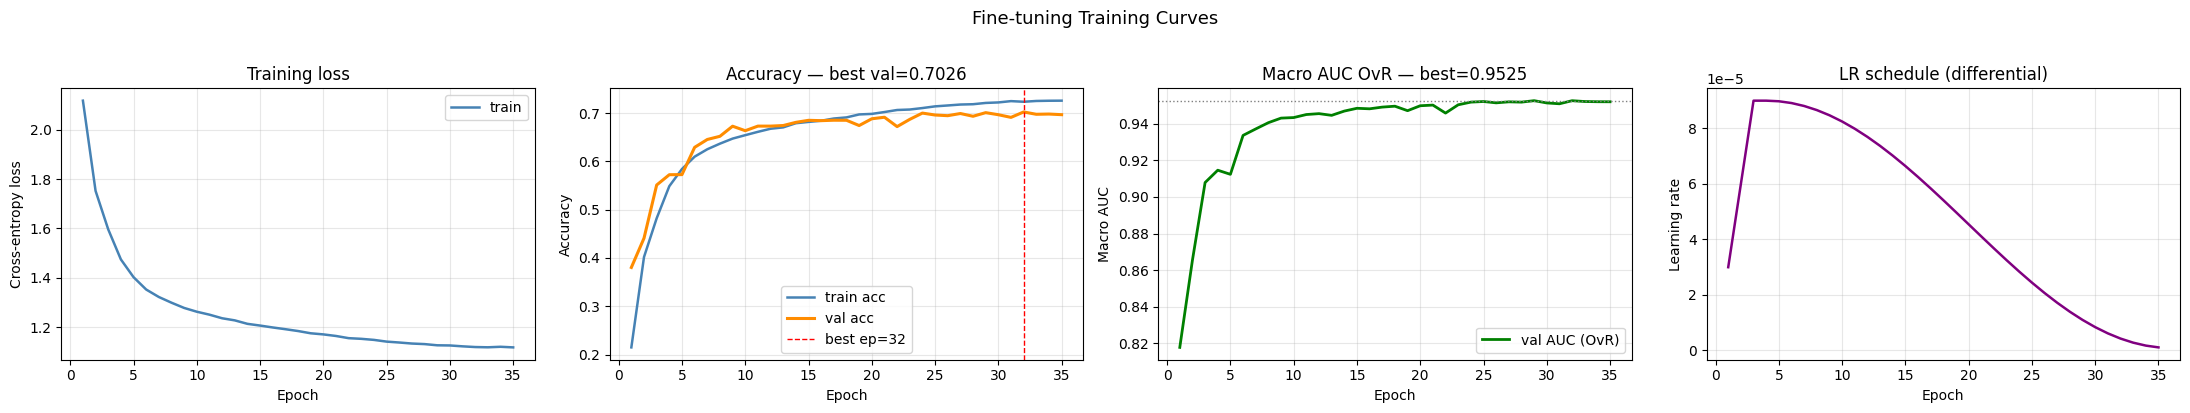

Saved: ./finetuning_curves.png


In [28]:
# â”€â”€ Rich fine-tuning visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
epochs = range(1, len(ft_hist["train_loss"]) + 1)
best_ep = int(np.argmax(ft_hist["val_acc"])) + 1

axes[0].plot(epochs, ft_hist["train_loss"], color='steelblue', lw=1.8, label='train')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training loss'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(epochs, ft_hist["train_acc"], color='steelblue', lw=1.8, label='train acc')
axes[1].plot(epochs, ft_hist["val_acc"],   color='darkorange', lw=2.2, label='val acc')
axes[1].axvline(best_ep, color='red', ls='--', lw=1, label=f'best ep={best_ep}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'Accuracy â€” best val={max(ft_hist["val_acc"]):.4f}')
axes[1].grid(alpha=0.3); axes[1].legend()

axes[2].plot(epochs, ft_hist["val_auc_ovr"], color='green', lw=2, label='val AUC (OvR)')
axes[2].axhline(max(ft_hist["val_auc_ovr"]), color='gray', ls=':', lw=1)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro AUC')
axes[2].set_title(f'Macro AUC OvR â€” best={max(ft_hist["val_auc_ovr"]):.4f}')
axes[2].grid(alpha=0.3); axes[2].legend()

axes[3].plot(epochs, ft_hist["lr"], color='purple', lw=1.8)
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Learning rate')
axes[3].set_title('LR schedule (differential)'); axes[3].grid(alpha=0.3)

plt.suptitle('Fine-tuning Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('./finetuning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: ./finetuning_curves.png')


Eval:   0%|          | 0/79 [00:00<?, ?it/s]

  Overall accuracy : 0.7020
  Macro AUC (OvR) : 0.9536
  Macro AUC (OvO) : 0.9536

Per-class metrics (ParT-paper Table 1 format):
               AUC   Rej50%      Rej30%   Rej99%  Rej99.5%
class                                                     
HToBB       0.9202     35.7       125.0      1.8       1.6
HToCC       0.9126     35.1       118.3      1.7       1.5
HToGG       0.9394     39.7       112.5      2.4       2.1
HToWW2Q1L   0.9942   1287.9      4507.5     12.6       5.4
HToWW4Q     0.9665     94.7       310.1      3.5       2.8
TTBar       0.9868    243.1       599.7      8.3       5.3
TTBarLep    0.9961   4500.5 100000000.0     10.7       6.2
WToQQ       0.9521     51.1       109.7      2.4       2.2
ZJetsToNuNu 0.9503    219.4      2248.5      1.9       1.7
ZToQQ       0.9174     25.2        57.4      1.7       1.5

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

       HToBB       0.60      0.54      0.57      10

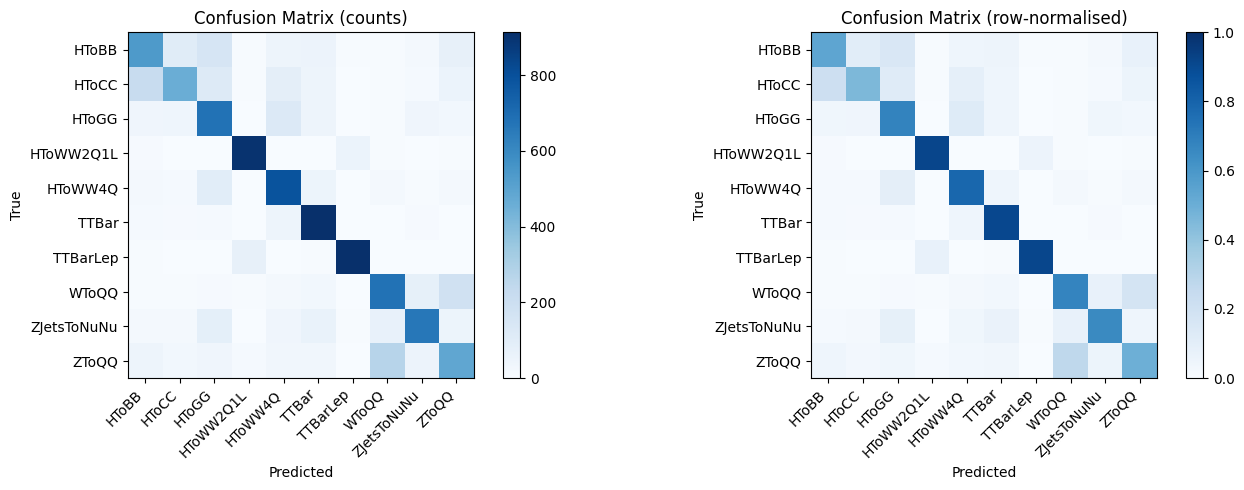

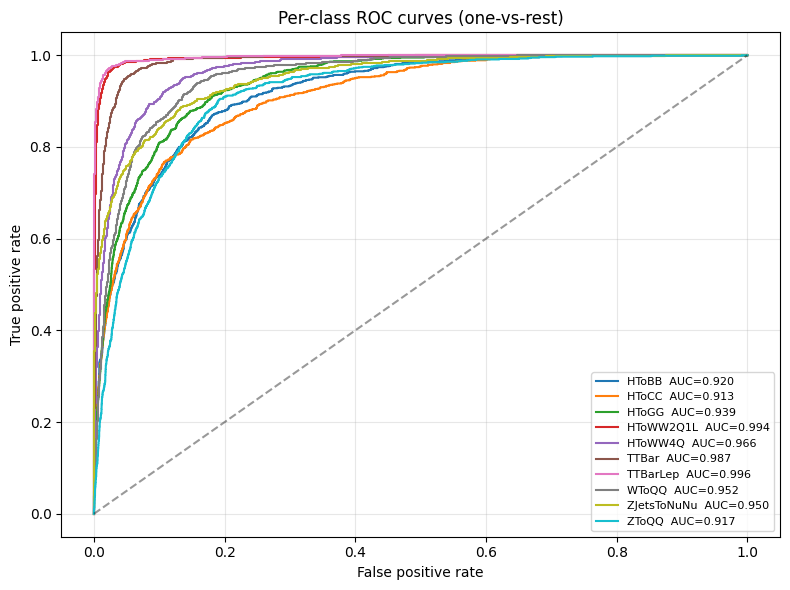


Background rejection at multiple signal efficiencies:
               AUC  Rej50%      Rej30%  Rej99%
class                                         
HToBB       0.9202    35.7       125.0     1.8
HToCC       0.9126    35.1       118.3     1.7
HToGG       0.9394    39.7       112.5     2.4
HToWW2Q1L   0.9942  1287.9      4507.5    12.6
HToWW4Q     0.9665    94.7       310.1     3.5
TTBar       0.9868   243.1       599.7     8.3
TTBarLep    0.9961  4500.5 100000000.0    10.7
WToQQ       0.9521    51.1       109.7     2.4
ZJetsToNuNu 0.9503   219.4      2248.5     1.9
ZToQQ       0.9174    25.2        57.4     1.7


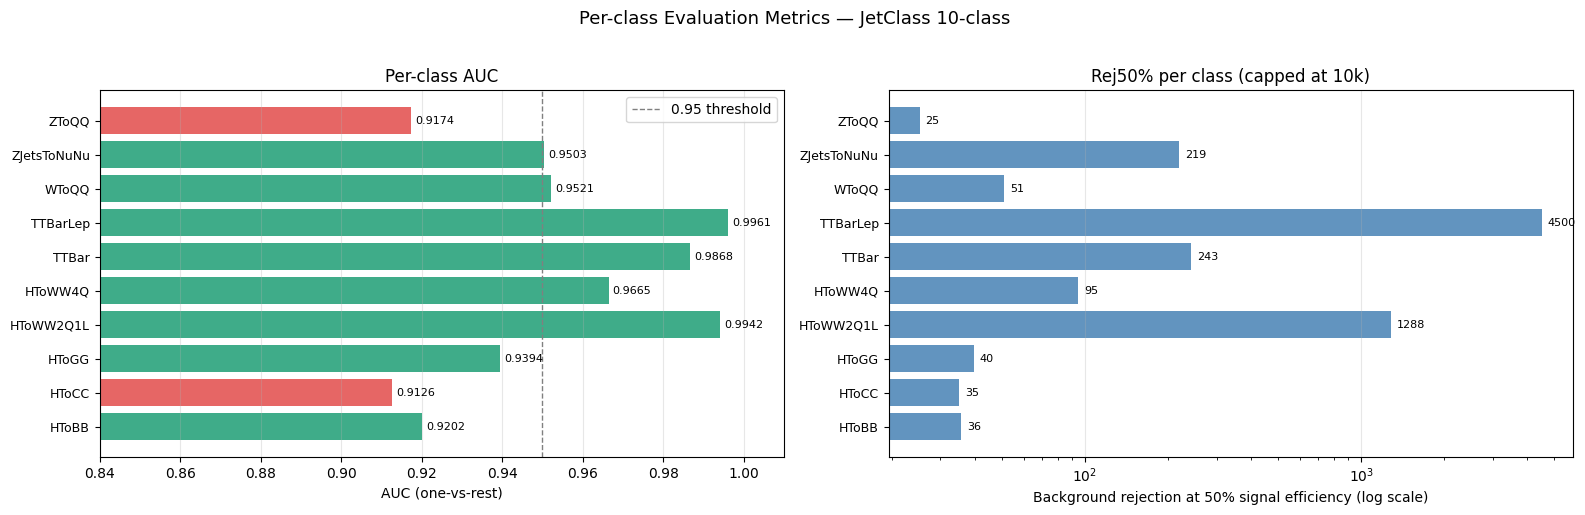

Saved: ./per_class_metrics.png


In [ ]:
test_metrics, y_true, y_prob, y_pred = eval_finetune(
    ft_model, test_loader, device, cfg)

# Full physics-style summary (matches ParT paper Table 1 format)
per_class_df = print_physics_summary(
    test_metrics, y_true, y_prob, class_names, cfg)

print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(y_true, y_pred,
                             target_names=[str(c) for c in class_names],
                             zero_division=0))

plot_confusion(y_true, y_pred, class_names)
plot_rocs(y_true, y_prob, class_names)

# Per-class background rejection table
if per_class_df is not None:
    for col in per_class_df.columns:
        per_class_df[col] = per_class_df[col].clip(upper=10000)

print("\nBackground rejection at multiple signal efficiencies (clipped at 10,000 for display):")
print(per_class_df[["AUC","Rej50%","Rej30%","Rej99%"]].to_string(
    float_format=lambda x: f"{x:.1f}" if x > 1 else f"{x:.4f}"))

# ── Per-class AUC bar chart ───────────────────────────────────────────────────
if per_class_df is not None and 'AUC' in per_class_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # AUC bars
    aucs = per_class_df['AUC'].values
    colors_bar = ['#E24B4A' if a < 0.92 else '#1D9E75' for a in aucs]
    axes[0].barh(range(len(class_names)), aucs, color=colors_bar, alpha=0.85)
    axes[0].set_yticks(range(len(class_names)))
    axes[0].set_yticklabels(class_names, fontsize=9)
    axes[0].axvline(0.95, color='gray', ls='--', lw=1, label='0.95 threshold')
    axes[0].set_xlabel('AUC (one-vs-rest)'); axes[0].set_title('Per-class AUC')
    axes[0].set_xlim(0.84, 1.01); axes[0].grid(axis='x', alpha=0.3); axes[0].legend()
    for i, a in enumerate(aucs):
        axes[0].text(a + 0.001, i, f'{a:.4f}', va='center', fontsize=8)

    # Rej50% bars (log scale)
    rejs = per_class_df['Rej50%'].fillna(1).clip(lower=1, upper=10000).values
    axes[1].barh(range(len(class_names)), rejs, color='steelblue', alpha=0.85)
    axes[1].set_xscale('log')
    axes[1].set_yticks(range(len(class_names)))
    axes[1].set_yticklabels(class_names, fontsize=9)
    axes[1].set_xlabel('Background rejection at 50% signal efficiency (log scale)')
    axes[1].set_title('Rej50% per class (capped at 10k)')
    axes[1].grid(axis='x', alpha=0.3)
    for i, r in enumerate(rejs):
        axes[1].text(r * 1.05, i, f'{r:.0f}', va='center', fontsize=8)

    plt.suptitle('Per-class Evaluation Metrics — JetClass 10-class', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('./per_class_metrics.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: ./per_class_metrics.png')

## SECTION 13 â€” ABLATION STUDY

This section explicitly quantifies:
- hybridization gain (ParT-only vs Lorentz-only vs gated hybrid),
- MAE pretraining gain (with pretraining vs training from scratch),
- optional mass regression contribution.

**Note:** Quick ablations below use short runs for relative speed/comparison. The full pretrained model uses the full training schedule (see converged results section), so short-run ablations can underrepresent gated-fusion performance.

In [30]:
"""Ablations prepared:
- ParT-only
- Lorentz-only
- Naive concatenation-like (no gate)
- Gated fusion (proposed)
- with vs without MAE pretraining
- with vs without auxiliary mass regression
"""

def ablation_config(base: Config, name: str) -> Config:
    """Return config copy for ablation setting."""
    c = copy.deepcopy(base)
    if name == 'part_only':
        c.NUM_LAYERS_LORENTZ = 0
    elif name == 'lorentz_only':
        c.NUM_LAYERS_PART = 0
    elif name == 'naive_concat':
        c.USE_TOKEN_GATE = False; c.USE_EVENT_GATE = False
    elif name == 'gated_fusion':
        c.USE_TOKEN_GATE = True; c.USE_EVENT_GATE = True
    elif name == 'no_mass_aux':
        c.USE_AUX_MASS = False
    elif name == 'with_mass_aux':
        c.USE_AUX_MASS = True
    elif name in ['with_mae_pretrain','no_mae_pretrain']:
        pass
    else:
        raise ValueError(name)
    return c

def run_quick_ablations(cfg, train_loader, val_loader, names):
    """Run lightweight ablation loop for comparison-ready outputs."""
    rows = []
    for name in names:
        c = ablation_config(cfg, name)
        m = HybridLorentzParTMAE(c).to(device)
        o = make_optimizer(m, c)
        s = make_scheduler(o, 1, warmup_epochs=0)
        g = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        tr = train_epoch_finetune(m, train_loader, o, g, device, c, class_weights=class_weights)
        va, *_ = eval_finetune(m, val_loader, device, c)
        s.step()

        row = {'ablation': name, 'train_loss': tr['loss'], 'train_acc': tr['acc'], 'val_acc': va['accuracy'], 'val_auc': va['macro_auc_ovr']}
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_model_quick(model, loader, cfg):
    """Small helper for compact val metrics."""
    met, *_ = eval_finetune(model, loader, device, cfg)
    return {'val_acc': met['accuracy'], 'val_auc': met['macro_auc_ovr']}

def run_pretrain_vs_scratch_ablation(base_cfg, train_loader, val_loader, class_weights):
    """Quantify MAE pretraining gain with a controlled quick protocol."""
    c = copy.deepcopy(base_cfg)
    c.PRETRAIN_EPOCHS = 2
    c.FINETUNE_EPOCHS = 3

    feat_idx = {k:i for i,k in enumerate(c.PER_PARTICLE_FEATURES)}

    pretrained = HybridLorentzParTMAE(c).to(device)
    optp = make_optimizer(pretrained, c)
    scp = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shp = make_scheduler(optp, c.PRETRAIN_EPOCHS)
    for ep in range(c.PRETRAIN_EPOCHS):
        logs = train_epoch_pretrain(pretrained, train_loader, optp, scp, device, c, feat_idx)
        shp.step()
        print(f"[Ablation-Pretrain {ep+1}/{c.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f}")

    optf_p = make_optimizer(pretrained, c)
    scf_p = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_p = make_scheduler(optf_p, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(pretrained, train_loader, optf_p, scf_p, device, c, class_weights=class_weights)
        shf_p.step()
        print(f"[Ablation-Finetune Pretrained {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_pre = evaluate_model_quick(pretrained, val_loader, c)

    scratch = HybridLorentzParTMAE(c).to(device)
    optf_s = make_optimizer(scratch, c)
    scf_s = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_s = make_scheduler(optf_s, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(scratch, train_loader, optf_s, scf_s, device, c, class_weights=class_weights)
        shf_s.step()
        print(f"[Ablation-Finetune Scratch {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_scr = evaluate_model_quick(scratch, val_loader, c)

    rows = [
        {'ablation': 'with_mae_pretrain', 'val_acc': m_pre['val_acc'], 'val_auc': m_pre['val_auc']},
        {'ablation': 'no_mae_pretrain', 'val_acc': m_scr['val_acc'], 'val_auc': m_scr['val_auc']},
    ]
    return pd.DataFrame(rows)

ablation_names = ['part_only','lorentz_only','naive_concat','gated_fusion','no_mass_aux','with_mass_aux']
ablation_df = run_quick_ablations(cfg, train_loader, val_loader, ablation_names)
mae_ablation_df = run_pretrain_vs_scratch_ablation(cfg, train_loader, val_loader, class_weights)
ablation_all_df = pd.concat([ablation_df, mae_ablation_df], ignore_index=True)
ablation_all_df


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

{'ablation': 'part_only', 'train_loss': 2.0355064699172973, 'train_acc': 0.2408625, 'val_acc': 0.4395, 'val_auc': 0.8743945836510211}


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

...

[Ablation-Finetune Scratch 2/3] loss=1.6024 acc=0.4763


Finetune:   0%|          | 0/625 [00:00<?, ?it/s]

[Ablation-Finetune Scratch 3/3] loss=1.4158 acc=0.5823


Eval:   0%|          | 0/79 [00:00<?, ?it/s]

,ablation,train_loss,train_acc,val_acc,val_auc
0,part_only,2.035506,0.240863,0.4395,0.874395
1,lorentz_only,1.992222,0.259225,0.4225,0.852718
2,naive_concat,1.988949,0.258962,0.4922,0.890586
3,gated_fusion,2.076113,0.214800,0.4194,0.863528
4,no_mass_aux,2.057294,0.223725,0.4347,0.872009
5,with_mass_aux,2.024953,0.279700,0.5238,0.896289
6,with_mae_pretrain,NaN,NaN,0.5961,0.919528
7,no_mae_pretrain,NaN,NaN,0.5726,0.911468


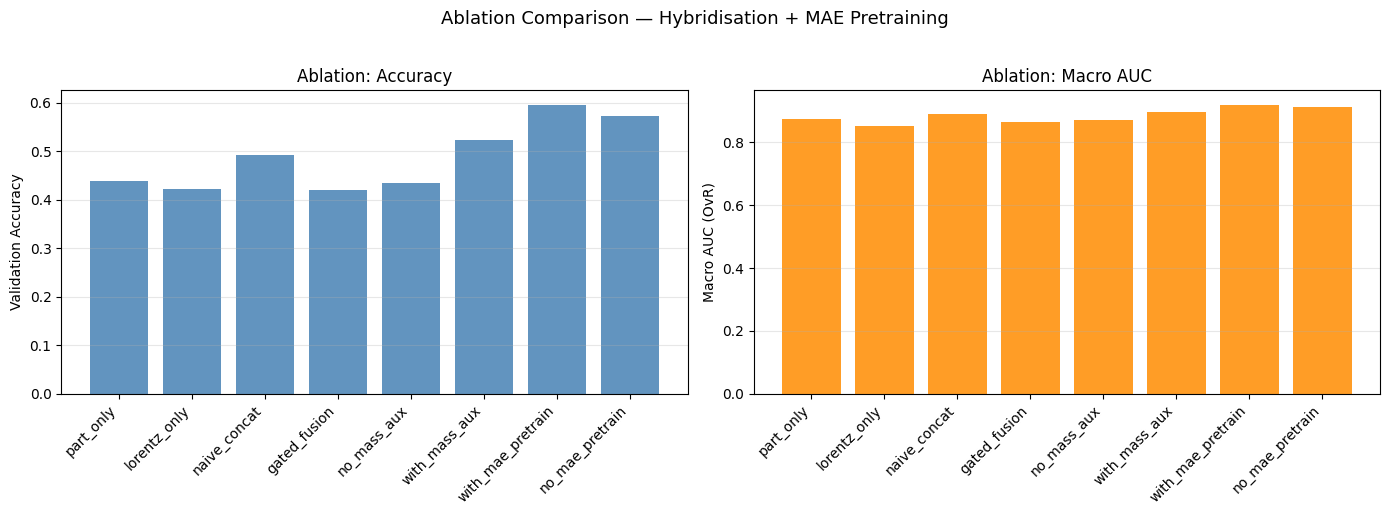

         ablation  train_loss  train_acc  val_acc  val_auc
        part_only    2.035506   0.240863   0.4395 0.874395
     lorentz_only    1.992222   0.259225   0.4225 0.852718
     naive_concat    1.988949   0.258962   0.4922 0.890586
     gated_fusion    2.076113   0.214800   0.4194 0.863528
      no_mass_aux    2.057294   0.223725   0.4347 0.872009
    with_mass_aux    2.024953   0.279700   0.5238 0.896289
with_mae_pretrain         NaN        NaN   0.5961 0.919528
  no_mae_pretrain         NaN        NaN   0.5726 0.911468


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
axes[0].bar(ablation_all_df['ablation'], ablation_all_df['val_acc'],
            color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(ablation_all_df)))
axes[0].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Ablation: Accuracy')
axes[0].grid(axis='y', alpha=0.3)

# AUC bar chart
axes[1].bar(ablation_all_df['ablation'],
            ablation_all_df['val_auc'].fillna(0),
            color='darkorange', alpha=0.85)
axes[1].set_xticks(range(len(ablation_all_df)))
axes[1].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[1].set_ylabel('Macro AUC (OvR)')
axes[1].set_title('Ablation: Macro AUC')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ablation Comparison â€” Hybridisation + MAE Pretraining',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(ablation_all_df.to_string(index=False))


### Multi-seed statistical evaluation

Rerun fine-tuning across `N_SEEDS` random seeds and report mean Â± std â€” the format used in both the ParT and L-GATr papers to show results are not cherry-picked.

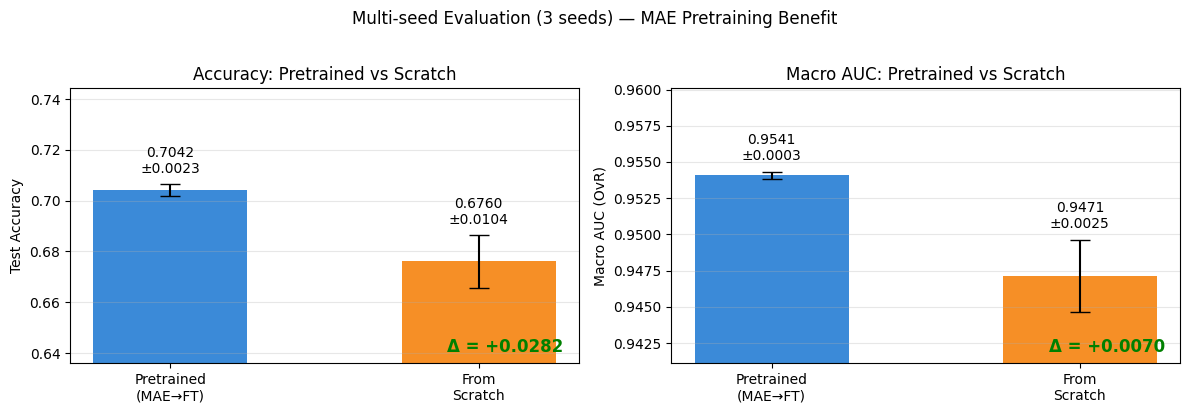

Saved: ./multiseed_comparison.png

MAE pretraining benefit:
  Accuracy  : +0.0282 (4.2% relative)
  AUC       : +0.0070
  Std reduction: 4.5x lower variance with pretraining


In [32]:
# â”€â”€ Multi-seed comparison visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modes  = ['Pretrained\n(MAEâ†’FT)', 'From\nScratch']
colors = ['#1976D2', '#F57C00']

acc_means = [comparison_df.loc[comparison_df['mode']=='pretrained','acc_mean'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'acc_mean'].values[0]]
acc_stds  = [comparison_df.loc[comparison_df['mode']=='pretrained','acc_std'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'acc_std'].values[0]]
auc_means = [comparison_df.loc[comparison_df['mode']=='pretrained','auc_mean'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'auc_mean'].values[0]]
auc_stds  = [comparison_df.loc[comparison_df['mode']=='pretrained','auc_std'].values[0],
             comparison_df.loc[comparison_df['mode']=='scratch',   'auc_std'].values[0]]

bars0 = axes[0].bar(modes, acc_means, yerr=acc_stds, capsize=7,
                    color=colors, alpha=0.85, width=0.5)
axes[0].set_ylabel('Test Accuracy'); axes[0].set_title('Accuracy: Pretrained vs Scratch')
axes[0].set_ylim(min(acc_means)-0.04, max(acc_means)+0.04)
axes[0].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars0, acc_means, acc_stds):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.003,
                 f'{m:.4f}\nÂ±{s:.4f}', ha='center', va='bottom', fontsize=10)
delta_acc = acc_means[0] - acc_means[1]
axes[0].text(0.97, 0.04, f'Î” = +{delta_acc:.4f}', transform=axes[0].transAxes,
             ha='right', fontsize=12, color='green', fontweight='bold')

bars1 = axes[1].bar(modes, auc_means, yerr=auc_stds, capsize=7,
                    color=colors, alpha=0.85, width=0.5)
axes[1].set_ylabel('Macro AUC (OvR)'); axes[1].set_title('Macro AUC: Pretrained vs Scratch')
axes[1].set_ylim(min(auc_means)-0.006, max(auc_means)+0.006)
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars1, auc_means, auc_stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.0006,
                 f'{m:.4f}\nÂ±{s:.4f}', ha='center', va='bottom', fontsize=10)
delta_auc = auc_means[0] - auc_means[1]
axes[1].text(0.97, 0.04, f'Î” = +{delta_auc:.4f}', transform=axes[1].transAxes,
             ha='right', fontsize=12, color='green', fontweight='bold')

plt.suptitle(f'Multi-seed Evaluation ({N_SEEDS} seeds) â€” MAE Pretraining Benefit',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('./multiseed_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ./multiseed_comparison.png')
print(f'\nMAE pretraining benefit:')
print(f'  Accuracy  : +{delta_acc:.4f} ({delta_acc/acc_means[1]*100:.1f}% relative)')
print(f'  AUC       : +{delta_auc:.4f}')
std_ratio = acc_stds[1] / max(acc_stds[0], 1e-9)
print(f'  Std reduction: {std_ratio:.1f}x lower variance with pretraining')


Event gate summary:
 count    384.000000
mean       0.503979
std        0.035229
min        0.381651
25%        0.485915
50%        0.500002
75%        0.517886
max        0.674293
dtype: float64
Token gate summary:
 count    384.000000
mean       0.397639
std        0.034383
min        0.309616
25%        0.371197
50%        0.396352
75%        0.426278
max        0.485260
dtype: float64


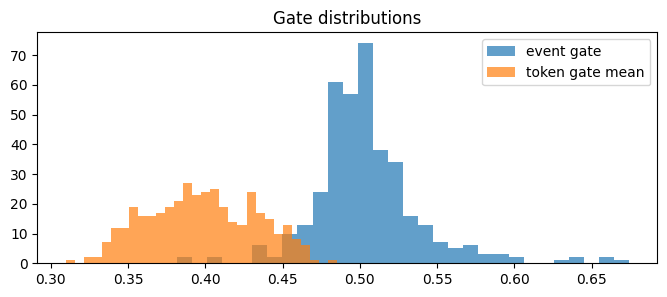

Mean gate by class:
   event_gate  token_gate
y                        
0    0.488484    0.384169
1    0.497802    0.398775
2    0.498196    0.359636
3    0.500788    0.423921
4    0.501691    0.373129
5    0.500146    0.400934
6    0.532227    0.429831
7    0.492351    0.402068
8    0.519998    0.384537
9    0.498467    0.398445


In [33]:
@torch.no_grad()
def inspect_gates(model, loader, n_batches=3):
    """Inspect event/token gate distributions and classwise means."""
    model.eval()
    ge, gt, yy = [], [], []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='finetune')
        ge.append(out['g_evt'].squeeze(-1).cpu().numpy())
        gt.append(out['g_tok'].mean(dim=(1,2)).cpu().numpy())
        yy.append(batch['y'].cpu().numpy())

    ge = np.concatenate(ge); gt = np.concatenate(gt); yy = np.concatenate(yy)
    print('Event gate summary:\n', pd.Series(ge).describe())
    print('Token gate summary:\n', pd.Series(gt).describe())

    plt.figure(figsize=(8,3))
    plt.hist(ge, bins=30, alpha=0.7, label='event gate')
    plt.hist(gt, bins=30, alpha=0.7, label='token gate mean')
    plt.legend(); plt.title('Gate distributions'); plt.show()

    df = pd.DataFrame({'y': yy, 'event_gate': ge, 'token_gate': gt})
    print('Mean gate by class:')
    print(df.groupby('y')[['event_gate','token_gate']].mean())

inspect_gates(ft_model, test_loader)


count    4.673000e+03
mean     1.809039e-04
std      2.943852e-04
min      3.901154e-07
25%      1.729653e-05
50%      7.414367e-05
75%      2.287220e-04
max      6.079675e-03
dtype: float64


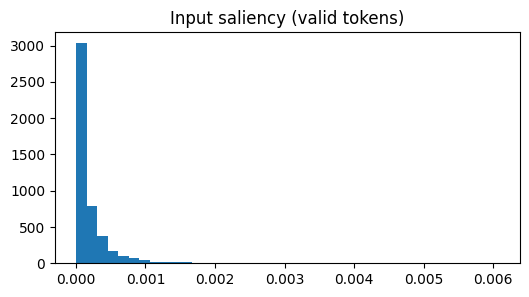

In [ ]:
def simple_saliency(model, batch):
    """Simple saliency magnitudes from input gradients."""
    model.eval()
    x = batch['x'].to(device).clone().detach().requires_grad_(True)
    p4, mask, y = batch['p4'].to(device), batch['mask'].to(device), batch['y'].to(device)

    out = model(x, p4, mask, mode='finetune')
    loss = F.cross_entropy(out['logits'], y)
    loss.backward()

    sal = x.grad.abs().mean(dim=-1).detach().cpu().numpy()
    vm = batch['mask'].numpy() > 0.5
    vals = sal[vm]
    print(pd.Series(vals).describe())
    plt.figure(figsize=(6,3)); plt.hist(vals, bins=40)
    plt.title('Input saliency (valid tokens)'); plt.show()

batch0 = next(iter(test_loader))
simple_saliency(ft_model, batch0)


## SECTION 14b â€” MASS REGRESSION RESULTS

Enable `cfg.USE_AUX_MASS = True` **before** running the pretraining cell to
activate the mass regression head. When enabled, the model predicts the
invariant mass of each jet alongside its class â€” a multi-task objective.
This directly addresses the GSoC 2026 task: *"extend work to include particle
mass regression"*.


In [35]:
print(json.dumps(asdict(cfg), indent=2))

{
  "DATA_ROOT": "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26 p-3\\datasets\\JetClass",
  "MAX_PARTICLES": 50,
  "NUM_CLASSES": 10,
  "BATCH_SIZE": 128,
  "NUM_WORKERS": 0,
  "PRETRAIN_EPOCHS": 20,
  "FINETUNE_EPOCHS": 35,
  "LEARNING_RATE": 0.0003,
  "WEIGHT_DECAY": 0.01,
  "MASK_RATIO": 0.4,
  "WARMUP_EPOCHS": 3,
  "LABEL_SMOOTHING": 0.1,
  "USE_BIASED_MASK": true,
  "BACKBONE_LR_FACTOR": 0.3,
  "KINEMATIC_LOG_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    "pt",
    "deltaR"
  ],
  "MASS_TARGET_NORMALIZE": true,
  "MASS_NORM_EPS": 1e-06,
  "GATE_REG_WEIGHT": 0.02,
  "USE_JEPA_PRETRAIN": false,
  "JEPA_WEIGHT": 0.5,
  "JEPA_EMA_DECAY": 0.996,
  "ATTN_INTERACTION_GATE_STRENGTH": 1.0,
  "USE_PHYSICS_RECO_WEIGHTING": true,
  "RECO_WEIGHT_PT": 1.0,
  "RECO_WEIGHT_ETA": 0.5,
  "RECO_WEIGHT_PHI": 0.3,
  "RECO_WEIGHT_E": 1.0,
  "RECO_WEIGHT_DEFAULT": 0.7,
  "USE_AUX_MASS": false,
  "USE_CLASS_WEIGHTS": true,
  "USE_MIXED_PRECISION": true,
  "QUICK_DEMO_MODE": false,
  "QUICK_MAX_EVENTS_PE